# Módulo 2 — Exploración guiada de modelos de demanda, versión 4

Esta versión conserva la progresión gradual del ejercicio original y añade challengers únicamente para cerrar brechas concretas:

1. comprender el problema y los datos;
2. establecer baselines difíciles de superar;
3. probar modelos lineales e inspeccionar sus supuestos;
4. introducir árboles y ensambles para capturar relaciones no lineales;
5. contrastar Extra Trees con boosting y un modelo temporal explícito;
6. seleccionar con desempeño, estabilidad, sesgo, interpretabilidad y costo;
7. promover un challenger solo cuando exista evidencia en varias ventanas nuevas.

**Pregunta analítica:** ¿cuánta energía total se demandará cada día durante el próximo mes?

**Unidad objetivo:** kWh/día. **Horizonte final:** último mes completo disponible, con pronóstico recursivo y sin observaciones reales futuras dentro del horizonte.


## Cómo recorrer el notebook

| Etapa | Pregunta | Alternativa | Puerta para continuar |
|---|---|---|---|
| 0. Referencia | ¿Qué tan difícil es el problema? | Último valor, estacional semanal, media móvil | Ningún modelo se acepta si no mejora una referencia pertinente |
| 1. Relación lineal | ¿Una combinación lineal de rezagos y calendario es suficiente? | Regresión lineal | Revisar VIF, residuales y desempeño temporal |
| 2. Regularización | ¿La colinealidad se controla sin perder interpretabilidad? | Ridge | Comparar sensibilidad a `alpha` |
| 3. No linealidad | ¿Hay reglas e interacciones que mejoren la predicción? | Árbol de decisión | Medir brecha entrenamiento–validación |
| 4. Reducción de varianza | ¿Un ensamble estabiliza al árbol? | Random Forest | Comparar estabilidad y costo |
| 5. Aleatoriedad adicional | ¿Cortes más aleatorios generalizan mejor? | Extra Trees | Conservar como champion provisional |
| 6. Boosting | ¿Corregir errores secuencialmente aporta una mejora consistente? | HistGradientBoosting | Exigir mejora en varios pliegues, no solo en el promedio |
| 7. Dinámica temporal | ¿Una estructura explícita de tendencia y semana compite con ML? | Holt-Winters | Comparar bajo las mismas ventanas cronológicas |

No se incluye clustering como candidato de pronóstico porque no estima directamente una demanda futura continua. Tampoco se ejecuta una búsqueda masiva: los challengers y sus configuraciones quedan definidos antes de observar la prueba final.


## Correspondencia con la rúbrica de evaluación

| Criterio | Implementación en esta versión |
|---|---|
| 2.1 Coherencia modelos–requerimientos | Mapa requisito → componente → modelo → métrica → evidencia → brecha |
| 2.2 Evaluación de alternativas | Baselines, modelos lineales, árbol, bagging, boosting y modelo temporal explícito bajo un protocolo común |
| 2.3 Supuestos y preparación | Calidad, ADF, VIF, Shapiro–Wilk, Durbin–Watson, Breusch–Pagan y diagnósticos visuales |
| 2.4 Entrenamiento, validación y calibración | Backtesting cronológico recursivo, sensibilidad, curva de aprendizaje, prueba final móvil e intervalo conformal |
| 2.5 Ajustes iterativos | Diario hipótesis → cambio → evidencia → decisión para cada etapa |
| 2.6 Plan del prototipo | Champion–challenger, regla de promoción, riesgos, responsables y respuesta de degradación |
| 2.7 Reproducibilidad | Datos consolidados, hashes, semilla, versiones, script de preparación, parámetros y exportaciones |


In [1]:
from __future__ import annotations

import hashlib
import json
import os
import platform
import sys
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
import scipy.stats as stats
import sklearn
import statsmodels
import statsmodels.api as sm
from IPython.display import Markdown, display
from scipy.stats import shapiro

from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

SEED = 42
TARGET_COL = "demanda_total_kwh"
CV_HORIZON_DAYS = 28
N_CV_SPLITS = 3
CALIBRATION_MONTHS = 2
ALPHA_INTERVAL = 0.10
CURRENT_CHAMPION_FAMILY = "extra_trees"
MIN_NEW_WINDOWS_FOR_PROMOTION = 3
MIN_RELATIVE_GAIN_FOR_PROMOTION = 0.03
NOTEBOOK_VERSION = "4.0.0-challengers"

np.random.seed(SEED)
print({
    "python": sys.version.split()[0], "pandas": pd.__version__, "numpy": np.__version__,
    "scikit_learn": sklearn.__version__, "scipy": scipy.__version__,
    "statsmodels": statsmodels.__version__, "semilla": SEED,
})


{'python': '3.13.7', 'pandas': '2.3.3', 'numpy': '2.3.3', 'scikit_learn': '1.7.2', 'scipy': '1.16.3', 'statsmodels': '0.14.5', 'semilla': 42}


In [2]:
configured = os.getenv("MODULO2_PROJECT_DIR")
current = Path.cwd().resolve()
candidates = [
    Path(configured).resolve() if configured else None,
    current,
    *current.parents,
    current / "pronostico-demanda-energia",
    Path("/content/pronostico-demanda-energia"),
    Path("/content/drive/MyDrive/Proyecto de Grado/pronostico-demanda-energia"),
]
seen = set()
unique_candidates = []
for candidate in candidates:
    if candidate is not None:
        candidate = candidate.resolve()
        if candidate not in seen:
            seen.add(candidate)
            unique_candidates.append(candidate)

PROJECT_DIR = next(
    (
        candidate
        for candidate in unique_candidates
        if (candidate / "data" / "processed" / "base_modelo_diaria.csv").exists()
    ),
    None,
)
if PROJECT_DIR is None:
    raise FileNotFoundError(
        "No se encontró data/processed. Clone el repositorio, cambie el directorio de trabajo "
        "a su raíz o defina MODULO2_PROJECT_DIR."
    )

DATA_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"
print(f"Repositorio activo: {PROJECT_DIR}")
print(f"Datos procesados: {DATA_DIR}")


Repositorio activo: C:\Users\DARLAN\Documents\Proyecto de grado\pronostico-demanda-energia
Datos procesados: C:\Users\DARLAN\Documents\Proyecto de grado\pronostico-demanda-energia\data\processed


# Parte I — Coherencia entre problema, requerimientos y evidencia

La selección no se basa solamente en “el menor error”. Primero se declara qué requisito cubre cada componente. Los elementos de interfaz, escenarios económicos y alertas que no se resuelven en este notebook se mantienen como brechas explícitas.


In [3]:
requirements_map = pd.DataFrame([
    ["R1", "Pronóstico y rango", "Modelos + intervalo conformal", "WAPE, cobertura, ancho", "Predicción OOT e intervalo", "Rango aún exploratorio"],
    ["R2", "Comparar con volumen de referencia", "Comparación mensual", "Diferencia absoluta y %", "Tabla real/modelo/referencia", "La interacción corresponde al dashboard"],
    ["R3", "Efecto económico", "No cubierto por el modelo", "Coherencia direccional", "—", "Requiere parámetros comerciales"],
    ["R4", "Baseline y modelo candidato", "Etapas 0–7", "WAPE, MAE, RMSE, sesgo", "Leaderboard temporal", "Revalidar con 2026"],
    ["R5", "Evitar fuga futura", "Split cronológico + recursión", "Cero fechas futuras", "Pruebas automáticas", "Auditar disponibilidad en producción"],
    ["R6", "Error al nivel de decisión", "Evaluación diaria y mensual", "WAPE, MAE, RMSE, sesgo", "Métricas CV/OOT", "Confirmar horizonte con negocio"],
    ["R7", "Incertidumbre", "Conformal separado", "Cobertura y ancho", "Dos meses calibran; último mes prueba", "Menos de dos ciclos"],
    ["R8", "Alertas atípicas", "Fuera del núcleo de pronóstico", "Revisión de alertas", "—", "Módulo posterior"],
    ["R9", "Reproducibilidad", "Hash + semilla + bitácora", "Diferencia <=1e-6", "Repetición automática", "Fijar imagen de ejecución futura"],
    ["R10", "Integrar TC1/TC2", "Preprocesamiento reproducible", "Periodos y conteos disponibles", "reporte_calidad.json", "Actualizar cuando exista demanda real 2026"],
    ["R11", "Calidad y cadencias", "Reglas de calendarización", "Válida, duplicada o inválida", "Reporte de calidad", "Actualizar cierres cuando lleguen nuevas fuentes"],
    ["R12", "Visualización con filtros", "No cubierto por notebook", "Flujos funcionales", "—", "Implementar en prototipo"],
    ["R13", "Exportación", "Carpeta de corrida", "Campos y cifras", "CSV + JSON", "Conectar al frontend"],
    ["R14", "Privacidad", "Datos agregados", "Cero identificadores", "Auditoría de columnas", "Escanear repositorio en CI"],
    ["R15", "Flujo para usuarios", "No cubierto por modelo", "Prueba de usuarios", "—", "Validación del prototipo"],
    ["R16", "Clima/calendario opcional", "Calendario sí; clima no", "Comparación con/sin", "Festivos y ciclos", "Incluir clima solo con evidencia"],
    ["R17", "Sensibilidad económica", "No cubierto", "Casos límite", "—", "Módulo de escenarios"],
    ["R18", "Tiempo razonable", "Cronometría por candidato", "Tiempo de ajuste", "fit_seconds", "Medir también en infraestructura final"],
], columns=["requisito", "necesidad", "componente", "metrica", "evidencia", "brecha_plan_cierre"])
display(requirements_map)


,requisito,necesidad,componente,metrica,evidencia,brecha_plan_cierre
0,R1,Pronóstico y rango,Modelos + intervalo conformal,"WAPE, cobertura, ancho",Predicción OOT e intervalo,Rango aún exploratorio
1,R2,Comparar con volumen de referencia,Comparación mensual,Diferencia absoluta y %,Tabla real/modelo/referencia,La interacción corresponde al dashboard
2,R3,Efecto económico,No cubierto por el modelo,Coherencia direccional,—,Requiere parámetros comerciales
3,R4,Baseline y modelo candidato,Etapas 0–7,"WAPE, MAE, RMSE, sesgo",Leaderboard temporal,Revalidar con 2026
4,R5,Evitar fuga futura,Split cronológico + recursión,Cero fechas futuras,Pruebas automáticas,Auditar disponibilidad en producción
5,R6,Error al nivel de decisión,Evaluación diaria y mensual,"WAPE, MAE, RMSE, sesgo",Métricas CV/OOT,Confirmar horizonte con negocio
6,R7,Incertidumbre,Conformal separado,Cobertura y ancho,Dos meses calibran; último mes prueba,Menos de dos ciclos
7,R8,Alertas atípicas,Fuera del núcleo de pronóstico,Revisión de alertas,—,Módulo posterior
8,R9,Reproducibilidad,Hash + semilla + bitácora,Diferencia <=1e-6,Repetición automática,Fijar imagen de ejecución futura
9,R10,Integrar TC1/TC2,Preprocesamiento reproducible,Periodos y conteos disponibles,reporte_calidad.json,Actualizar cuando exista demanda real 2026


# Parte II — Datos, preparación y supuestos previos

## 1. Carga y controles

La variable objetivo continúa siendo la demanda real diaria agregada (`DMRE + DMNR`). TC1 y TC2 amplían la calidad, las cadencias, la segmentación y la conciliación, pero no se incorporan como predictores contemporáneos porque se conocen después del consumo.

Cuando lleguen archivos hasta agosto de 2026, primero debe regenerarse `base_modelo_diaria.csv`. El notebook solo utilizará los meses adicionales para validar el predictor si la base procesada contiene demanda real diaria comparable para esas fechas. La existencia de más facturas, por sí sola, no equivale a nuevas observaciones del objetivo.


In [4]:
base = pd.read_csv(DATA_DIR / "base_modelo_diaria.csv", parse_dates=["fecha"], encoding="utf-8-sig")
monthly_reference = pd.read_csv(
    DATA_DIR / "comparacion_mensual.csv", parse_dates=["periodo"], encoding="utf-8-sig"
)
quality = json.loads((DATA_DIR / "reporte_calidad.json").read_text(encoding="utf-8"))
manifest = json.loads((DATA_DIR / "manifest.json").read_text(encoding="utf-8"))
base = base.sort_values("fecha").set_index("fecha")

DATA_START = base.index.min().normalize()
DATA_END = base.index.max().normalize()
expected_dates = pd.date_range(DATA_START, DATA_END, freq="D")
required_columns = {
    TARGET_COL, "demanda_regulada_kwh", "demanda_no_regulada_kwh",
    "consumo_facturado_calendarizado_total_kwh", "cobertura_calendarizacion_completa",
}
assert required_columns.issubset(base.columns)
assert base.index.is_unique and base.index.equals(expected_dates)
assert base[TARGET_COL].notna().all() and base[TARGET_COL].gt(0).all()
assert len(quality["monthly_quality"]) >= 13

forbidden_tokens = ["niu", "direccion", "predial", "cedula", "medidor", "latitud", "longitud"]
privacy_findings = [column for column in base.columns if any(token in column.lower() for token in forbidden_tokens)]
assert not privacy_findings and quality["output_checks"]["privacy"]["passed"]
assert abs(quality["output_checks"]["reconciliation_difference_kwh"]) <= 1e-4

last_complete_month_end = DATA_END if DATA_END.is_month_end else DATA_END - pd.offsets.MonthEnd(1)
OOT_END = pd.Timestamp(last_complete_month_end).normalize()
OOT_START = OOT_END.replace(day=1)
CALIBRATION_END = OOT_START - pd.Timedelta(days=1)
CALIBRATION_START = (OOT_START - pd.DateOffset(months=CALIBRATION_MONTHS)).normalize()
DEVELOPMENT_END = CALIBRATION_START - pd.Timedelta(days=1)
assert DEVELOPMENT_END >= DATA_START + pd.Timedelta(days=180), "Historia insuficiente para desarrollo, calibración y prueba final."

display(base.head())
print({
    "filas": len(base), "inicio": str(DATA_START.date()), "fin": str(DATA_END.date()),
    "desarrollo_hasta": str(DEVELOPMENT_END.date()),
    "calibracion": [str(CALIBRATION_START.date()), str(CALIBRATION_END.date())],
    "prueba_final": [str(OOT_START.date()), str(OOT_END.date())],
    "privacidad": "APROBADA",
})


,demanda_total_kwh,demanda_regulada_kwh,demanda_no_regulada_kwh,perdidas_total_kwh,perdidas_regulada_kwh,perdidas_no_regulada_kwh,consumo_facturado_calendarizado_total_kwh,consumo_facturado_mensual_kwh,consumo_facturado_trimestral_kwh,consumo_facturado_irregular_kwh,registros_facturacion_activos,dia_semana,es_fin_de_semana,mes,dia_del_ano,cobertura_calendarizacion_completa
fecha,,,,,,,,,,,,,,,,
2025-01-01,"2,308,917.1700","2,104,531.1400","204,386.0300","35,472.0500","31,815.9600","3,656.0900","2,261,558.0365","1,888,872.2161","372,662.1537",23.6667,568545,2,0,1,1,1
2025-01-02,"2,632,251.8500","2,392,960.2900","239,291.5600","35,334.9100","31,832.6500","3,502.2600","2,263,100.3804","1,888,872.2161","374,204.4977",23.6667,569713,3,0,1,2,1
2025-01-03,"2,696,044.4100","2,459,318.8900","236,725.5200","39,481.3000","35,754.1900","3,727.1100","2,264,490.0223","1,888,872.2161","375,594.1396",23.6667,570628,4,0,1,3,1
2025-01-04,"2,621,651.9700","2,390,634.8900","231,017.0800","42,070.0700","38,039.5100","4,030.5600","2,265,489.8882","1,888,872.2161","376,617.6721",0.0000,571320,5,1,1,4,1
2025-01-05,"2,435,310.6700","2,221,732.9300","213,577.7400","35,041.7300","31,693.7100","3,348.0200","2,265,597.9954","1,888,872.2161","376,725.7793",0.0000,571737,6,1,1,5,1


{'filas': 577, 'inicio': '2025-01-01', 'fin': '2026-07-31', 'desarrollo_hasta': '2026-04-30', 'calibracion': ['2026-05-01', '2026-06-30'], 'prueba_final': ['2026-07-01', '2026-07-31'], 'privacidad': 'APROBADA'}


In [5]:
quality_table = pd.DataFrame([
    {
        "periodo": item["periodo"],
        "filas_tc2": item["tc2"]["rows"],
        "validas": item["tc2"]["valid_rows"],
        "duplicadas": item["tc2"].get("duplicate_rows", 0),
        "invalidas_marcadas": item["tc2"].get("invalid_rows", 0),
        "cruce_tc1_pct": item["tc2"]["tc1_matched_rows"] / max(item["tc2"]["valid_rows"], 1),
        "energia_bruta_kwh": item["tc2"]["energy_raw_kwh"],
        "energia_asignada_2025_kwh": item["tc2"]["energy_allocated_2025_kwh"],
    }
    for item in quality["monthly_quality"]
])
display(quality_table.style.format({"cruce_tc1_pct": "{:.2%}", "energia_bruta_kwh": "{:,.0f}", "energia_asignada_2025_kwh": "{:,.0f}"}))

print("Tratamiento del cierre:", quality["calendarization_rule"]["boundary_effect"])


,periodo,filas_tc2,validas,duplicadas,invalidas_marcadas,cruce_tc1_pct,energia_bruta_kwh,energia_asignada_2025_kwh
0,2025-01,564705,564692,13,0,100.00%,"94,790,010","41,300,614"
1,2025-02,352398,352395,3,0,100.00%,"57,754,177","57,754,177"
2,2025-03,352590,352581,9,0,100.00%,"55,102,441","55,102,441"
3,2025-04,568197,568176,15,6,100.00%,"93,188,521","93,029,566"
4,2025-05,354533,354508,17,8,100.00%,"57,344,408","57,295,429"
5,2025-06,355215,354977,10,228,100.00%,"59,636,137","58,616,721"
6,2025-07,573447,573183,42,222,100.00%,"91,621,318","91,367,497"
7,2025-08,356859,356851,8,0,100.00%,"59,326,253","59,326,253"
8,2025-09,357737,357676,9,52,100.00%,"60,728,397","59,942,160"
9,2025-10,576528,576491,37,0,100.00%,"90,432,578","90,432,578"


Tratamiento del cierre: La calendarización queda cerrada hasta 2026-06-30; el mes que termina en 2026-07-31 requiere el TC2 del periodo siguiente


In [6]:
closing_items = [item for item in quality["monthly_quality"] if item["periodo"] == "2026-01"]
closing_text = ""
if closing_items:
    closing_energy = closing_items[0]["tc2"]["energy_allocated_2025_kwh"]
    closing_text = f" TC2 de enero de 2026 asigna **{closing_energy:,.0f} kWh** a días de 2025 y conserva la trazabilidad del cierre."

future_target_days = int((base.index > pd.Timestamp("2025-12-31")).sum())
target_extension = (
    f" La base contiene **{future_target_days} días** de demanda real posteriores a 2025, que se incorporan al esquema de ventanas móviles."
    if future_target_days
    else " La demanda real aún termina en 2025; los challengers se ejecutan como preparación y no pueden promoverse con evidencia nueva."
)
display(Markdown(
    f"### Conclusión de preparación de datos\n\n"
    f"La base se acepta para modelación entre **{DATA_START.date()}** y **{DATA_END.date()}**: no tiene nulos en la demanda, supera la auditoría de privacidad y concilia sus agregados."
    f"{closing_text}{target_extension}"
))


### Conclusión de preparación de datos

La base se acepta para modelación entre **2025-01-01** y **2026-07-31**: no tiene nulos en la demanda, supera la auditoría de privacidad y concilia sus agregados. TC2 de enero de 2026 asigna **55,232,577 kWh** a días de 2025 y conserva la trazabilidad del cierre. La base contiene **212 días** de demanda real posteriores a 2025, que se incorporan al esquema de ventanas móviles.

## 2. Exploración visual y supuestos temporales

Antes de entrenar se revisan cobertura, estacionalidad semanal, valores extremos y relación con la referencia disponible. ADF diagnostica raíz unitaria; no sustituye la inspección visual ni garantiza que exista suficiente historia anual.


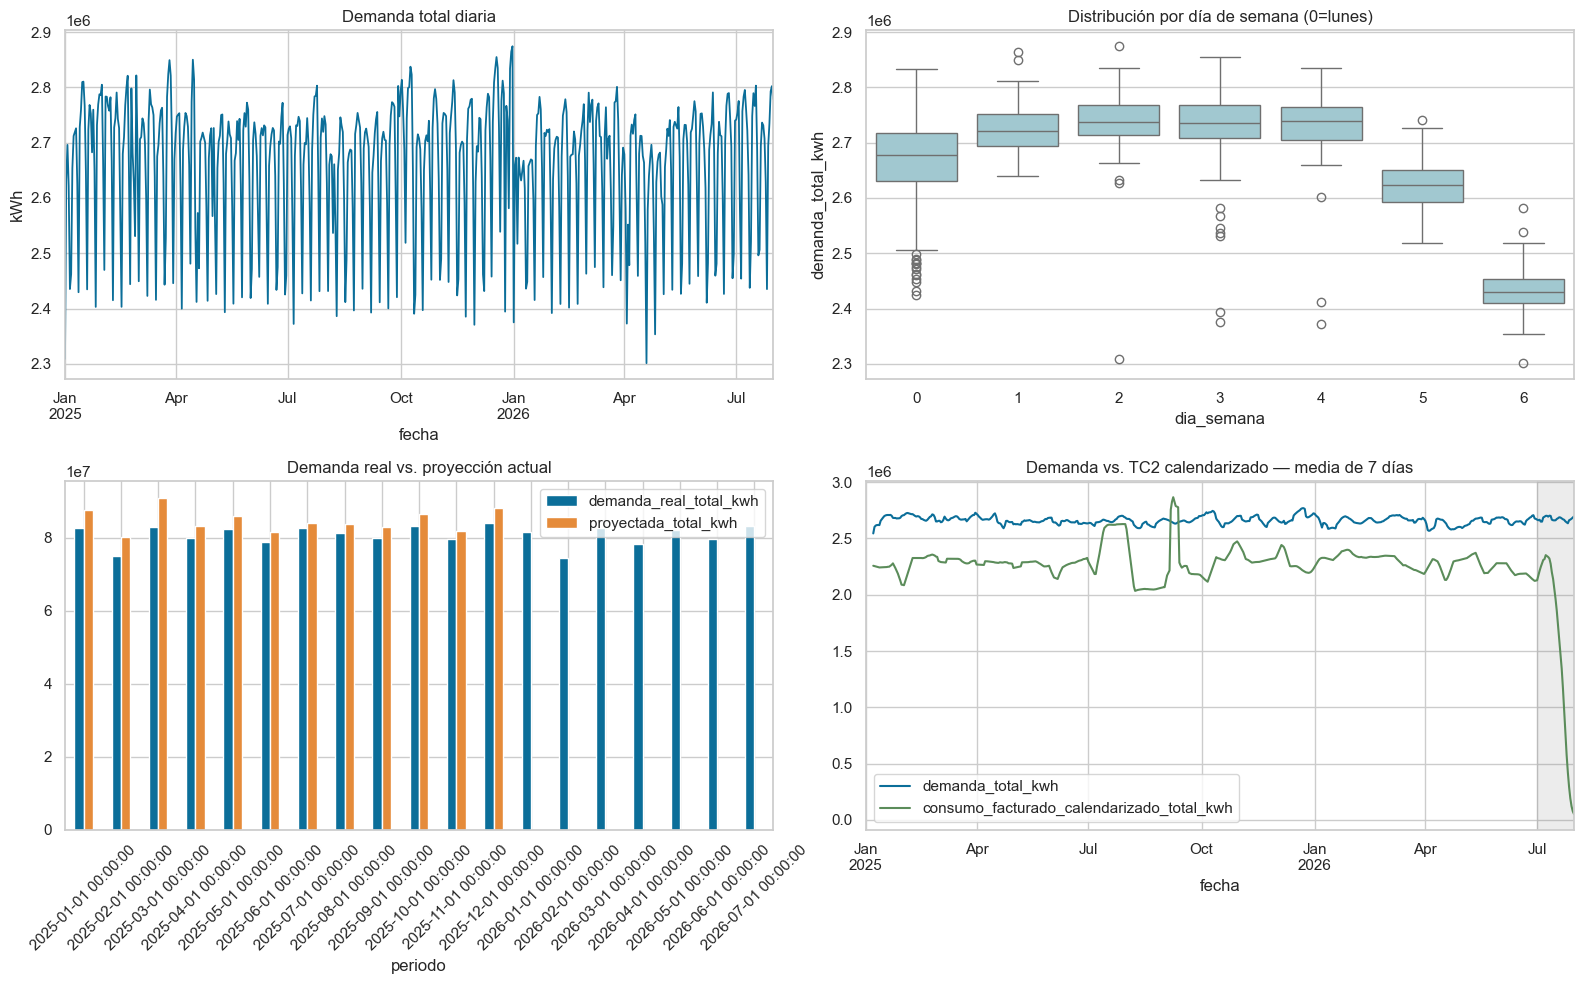

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
base[TARGET_COL].plot(ax=axes[0, 0], color="#0B6E99", linewidth=1.3)
axes[0, 0].set_title("Demanda total diaria")
axes[0, 0].set_ylabel("kWh")

sns.boxplot(data=base.reset_index(), x="dia_semana", y=TARGET_COL, ax=axes[0, 1], color="#99CDD8")
axes[0, 1].set_title("Distribución por día de semana (0=lunes)")

monthly_reference.set_index("periodo")[["demanda_real_total_kwh", "proyectada_total_kwh"]].plot(
    kind="bar", ax=axes[1, 0], color=["#0B6E99", "#E58B3A"]
)
axes[1, 0].set_title("Demanda real vs. proyección actual")
axes[1, 0].tick_params(axis="x", rotation=45)

base[[TARGET_COL, "consumo_facturado_calendarizado_total_kwh"]].rolling(7).mean().plot(
    ax=axes[1, 1], color=["#0B6E99", "#5B8C5A"]
)
axes[1, 1].axvspan(OOT_START, OOT_END, color="gray", alpha=0.15)
axes[1, 1].set_title("Demanda vs. TC2 calendarizado — media de 7 días")
plt.tight_layout()
plt.show()


{'ADF': -5.170338917758681, 'p_value': 1.010445548397455e-05, 'rezagos': 17, 'n': 559}


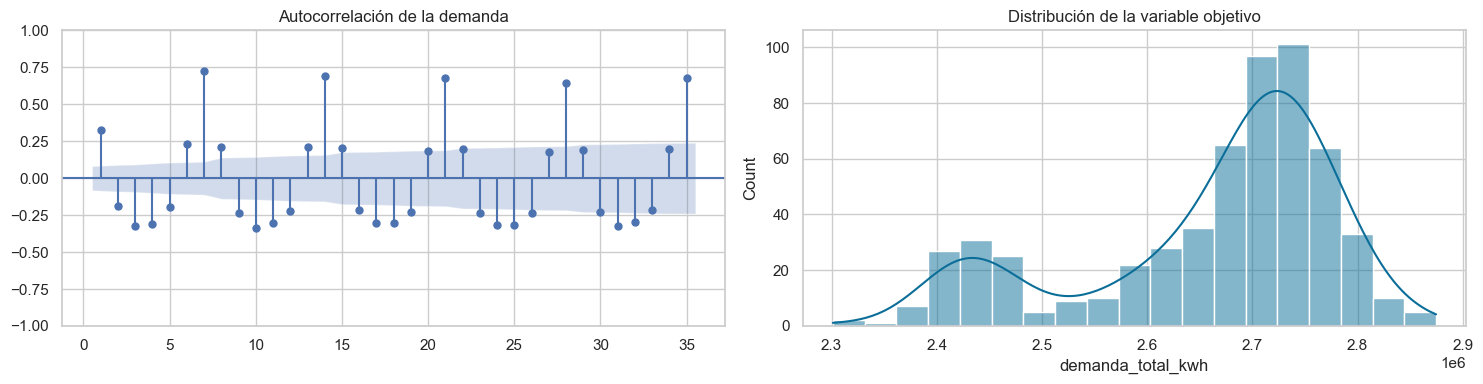

,demanda_total_kwh
count,577.0000
mean,"2,660,669.9694"
std,"121,235.6470"
min,"2,301,178.7800"
1%,"2,374,490.9832"
5%,"2,413,618.2780"
50%,"2,702,002.9500"
95%,"2,799,224.9940"
99%,"2,835,769.3688"
max,"2,874,545.3100"


In [8]:
y = base[TARGET_COL].astype(float).copy()
adf_stat, adf_pvalue, adf_lags, adf_nobs, *_ = adfuller(y, autolag="AIC")
print({"ADF": float(adf_stat), "p_value": float(adf_pvalue), "rezagos": adf_lags, "n": adf_nobs})

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(y, lags=35, ax=axes[0], zero=False)
axes[0].set_title("Autocorrelación de la demanda")
sns.histplot(y, kde=True, ax=axes[1], color="#0B6E99")
axes[1].set_title("Distribución de la variable objetivo")
plt.tight_layout()
plt.show()

display(y.describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]).to_frame("demanda_total_kwh"))


In [9]:
stationarity_text = "rechaza la hipótesis de raíz unitaria" if adf_pvalue < 0.05 else "no permite rechazar la hipótesis de raíz unitaria"
display(Markdown(
    f"### Conclusión de exploración\n\nLa prueba ADF {stationarity_text} con p={adf_pvalue:.4f}. "
    "La autocorrelación semanal observada justifica conservar rezagos de 7, 14 y 28 días. No se transforma la variable objetivo antes de probar los modelos sencillos."
))


### Conclusión de exploración

La prueba ADF rechaza la hipótesis de raíz unitaria con p=0.0000. La autocorrelación semanal observada justifica conservar rezagos de 7, 14 y 28 días. No se transforma la variable objetivo antes de probar los modelos sencillos.

## 3. Ingeniería de variables documentada

Todas las variables se pueden conocer al inicio del horizonte o se construyen exclusivamente con historia anterior:

- rezagos 1, 7, 14 y 28 días;
- media y desviación de los últimos 7 y 28 días;
- cambio respecto a la semana anterior;
- ciclos de día de semana y día del año;
- fin de semana y festivo colombiano;
- tendencia temporal.

No se incluyen TC2 calendarizado, pérdidas observadas del mismo día ni demanda real futura. El pronóstico es recursivo: las predicciones del propio horizonte alimentan los rezagos posteriores.


In [10]:
LAGS = (1, 7, 14, 28)
COLOMBIA_HOLIDAYS = pd.to_datetime([
    "2025-01-01", "2025-01-06", "2025-03-24", "2025-04-17", "2025-04-18",
    "2025-05-01", "2025-06-02", "2025-06-23", "2025-06-30", "2025-07-20",
    "2025-08-07", "2025-08-18", "2025-10-13", "2025-11-03", "2025-11-17",
    "2025-12-08", "2025-12-25", "2026-01-01", "2026-01-12", "2026-03-23",
    "2026-04-02", "2026-04-03", "2026-05-01", "2026-05-18", "2026-06-08",
    "2026-06-15", "2026-06-29", "2026-07-20", "2026-08-07", "2026-08-17",
    "2026-10-12", "2026-11-02", "2026-11-16", "2026-12-08", "2026-12-25",
])
FEATURE_COLUMNS = [
    "lag_1", "lag_7", "lag_14", "lag_28", "media_7", "desv_7",
    "media_28", "desv_28", "cambio_7", "dow_sin", "dow_cos",
    "doy_sin", "doy_cos", "es_fin_semana", "es_festivo", "tendencia",
]

def build_feature_row(history: pd.Series, forecast_date: pd.Timestamp) -> dict[str, float]:
    history = history.sort_index()
    if len(history) < max(LAGS):
        raise ValueError("Historia insuficiente para los rezagos.")
    values = history.to_numpy(dtype=float)
    dow, doy = forecast_date.dayofweek, forecast_date.dayofyear
    return {
        "lag_1": values[-1], "lag_7": values[-7], "lag_14": values[-14], "lag_28": values[-28],
        "media_7": values[-7:].mean(), "desv_7": values[-7:].std(ddof=0),
        "media_28": values[-28:].mean(), "desv_28": values[-28:].std(ddof=0),
        "cambio_7": values[-1] - values[-7],
        "dow_sin": np.sin(2 * np.pi * dow / 7), "dow_cos": np.cos(2 * np.pi * dow / 7),
        "doy_sin": np.sin(2 * np.pi * doy / 365.25), "doy_cos": np.cos(2 * np.pi * doy / 365.25),
        "es_fin_semana": float(dow >= 5),
        "es_festivo": float(forecast_date.normalize() in COLOMBIA_HOLIDAYS),
        "tendencia": float((forecast_date - DATA_START).days / 365.25),
    }

def make_supervised(series: pd.Series) -> tuple[pd.DataFrame, pd.Series]:
    rows, target, dates = [], [], []
    series = series.sort_index()
    for position in range(max(LAGS), len(series)):
        date = series.index[position]
        rows.append(build_feature_row(series.iloc[:position], date))
        target.append(float(series.iloc[position]))
        dates.append(date)
    X = pd.DataFrame(rows, index=dates)[FEATURE_COLUMNS]
    return X, pd.Series(target, index=dates, name="y")

def recursive_forecast(estimator, history: pd.Series, future_dates: pd.DatetimeIndex) -> pd.Series:
    simulated = history.copy().astype(float)
    predictions = []
    for date in future_dates:
        row = pd.DataFrame([build_feature_row(simulated, date)], columns=FEATURE_COLUMNS)
        prediction = max(0.0, float(estimator.predict(row)[0]))
        predictions.append(prediction)
        simulated.loc[date] = prediction
    return pd.Series(predictions, index=future_dates, name="prediccion")


In [11]:
display(Markdown(
    "### Conclusión de ingeniería de variables\n\n"
    "Se aprueba un conjunto pequeño de rezagos, estadísticas móviles, tendencia y calendario. "
    "Se excluyen pérdidas del mismo día y TC2 contemporáneo para evitar fuga de información; cualquier aporte futuro de facturación deberá entrar con rezago compatible con su fecha real de disponibilidad."
))


### Conclusión de ingeniería de variables

Se aprueba un conjunto pequeño de rezagos, estadísticas móviles, tendencia y calendario. Se excluyen pérdidas del mismo día y TC2 contemporáneo para evitar fuga de información; cualquier aporte futuro de facturación deberá entrar con rezago compatible con su fecha real de disponibilidad.

# Parte III — Protocolo común de evaluación

## Métricas elegidas

- **WAPE** es la métrica primaria: expresa el error absoluto total como proporción de la energía real total y se interpreta directamente a nivel del portafolio.
- **MAE** conserva la unidad kWh/día y es menos sensible a extremos.
- **RMSE** penaliza con mayor fuerza errores grandes, relevantes para días de alta desviación.
- **Sesgo** muestra sobrecompra o subestimación sistemática.
- **R²** se conserva como diagnóstico, pero no selecciona el modelo.

Accuracy, precision, recall y F1 no aplican porque el objetivo es continuo. MAPE no es la métrica principal porque pondera cada día por separado y puede volverse inestable cerca de cero; WAPE agrega primero la energía.


In [12]:
def regression_metrics(actual: pd.Series, predicted: pd.Series) -> dict[str, float]:
    actual, predicted = actual.align(predicted, join="inner")
    error = predicted - actual
    denominator = max(float(actual.abs().sum()), 1e-12)
    return {
        "wape": float(error.abs().sum() / denominator),
        "mae": float(mean_absolute_error(actual, predicted)),
        "rmse": float(mean_squared_error(actual, predicted) ** 0.5),
        "sesgo_pct": float(error.sum() / denominator),
        "r2": float(r2_score(actual, predicted)),
    }

def rolling_splits(series: pd.Series, n_splits: int, horizon: int):
    first_validation = len(series) - n_splits * horizon
    if first_validation < 120:
        raise ValueError("Historia insuficiente para estos pliegues.")
    for split_id in range(n_splits):
        start = first_validation + split_id * horizon
        train, validation = series.iloc[:start], series.iloc[start:start + horizon]
        assert train.index.max() < validation.index.min()
        yield split_id + 1, train, validation

def baseline_forecast(name: str, history: pd.Series, future_dates: pd.DatetimeIndex) -> pd.Series:
    simulated = history.copy().astype(float)
    predictions = []
    for date in future_dates:
        if name == "ultimo_valor":
            value = float(simulated.iloc[-1])
        elif name == "estacional_7":
            value = float(simulated.iloc[-7])
        elif name == "media_movil_7":
            value = float(simulated.iloc[-7:].mean())
        else:
            raise ValueError(name)
        predictions.append(max(0.0, value))
        simulated.loc[date] = value
    return pd.Series(predictions, index=future_dates, name=name)

def build_estimator(family: str, params: dict):
    if family == "regresion_lineal":
        return Pipeline([("scale", StandardScaler()), ("model", LinearRegression())])
    if family == "ridge":
        return Pipeline([("scale", StandardScaler()), ("model", Ridge(**params))])
    if family == "arbol":
        return DecisionTreeRegressor(random_state=SEED, **params)
    if family == "random_forest":
        return RandomForestRegressor(random_state=SEED, n_jobs=-1, **params)
    if family == "extra_trees":
        return ExtraTreesRegressor(random_state=SEED, n_jobs=-1, **params)
    if family == "hist_gradient_boosting":
        return HistGradientBoostingRegressor(random_state=SEED, **params)
    raise ValueError(family)

def fit_forecaster(family: str, params: dict, train: pd.Series):
    if family == "holt_winters":
        estimator = ExponentialSmoothing(
            train.astype(float), trend=params["trend"], damped_trend=params["damped_trend"],
            seasonal=params["seasonal"], seasonal_periods=params["seasonal_periods"],
            initialization_method="estimated",
        ).fit(optimized=True, remove_bias=False)
        fitted = pd.Series(np.asarray(estimator.fittedvalues), index=train.index)
        warmup = max(28, 2 * params["seasonal_periods"])
        y_train = train.iloc[warmup:]
        train_pred = fitted.loc[y_train.index]
        return estimator, None, y_train, train_pred
    X_train, y_train = make_supervised(train)
    estimator = build_estimator(family, params)
    estimator.fit(X_train, y_train)
    train_pred = pd.Series(estimator.predict(X_train), index=y_train.index)
    return estimator, X_train, y_train, train_pred

def forecast_forecaster(estimator, family: str, history: pd.Series, future_dates: pd.DatetimeIndex) -> pd.Series:
    if family == "holt_winters":
        values = np.maximum(0.0, np.asarray(estimator.forecast(len(future_dates)), dtype=float))
        return pd.Series(values, index=future_dates, name="prediccion")
    return recursive_forecast(estimator, history, future_dates)

development = y.loc[:DEVELOPMENT_END]
CV_SPLITS = list(rolling_splits(development, N_CV_SPLITS, CV_HORIZON_DAYS))
experiment_rows, prediction_rows, iteration_journal = [], [], []
model_registry = {}

def evaluate_candidate(stage: str, label: str, family: str, params: dict) -> pd.DataFrame:
    model_registry[label] = {"family": family, "params": params}
    stage_rows = []
    for fold, train, validation in CV_SPLITS:
        start = time.perf_counter()
        estimator, _, y_train, train_pred = fit_forecaster(family, params, train)
        fit_seconds = time.perf_counter() - start
        train_metrics = regression_metrics(y_train, train_pred)
        validation_pred = forecast_forecaster(estimator, family, train, validation.index)
        validation_metrics = regression_metrics(validation, validation_pred)
        row = {
            "etapa": stage, "label": label, "familia": family,
            "configuracion": json.dumps(params, sort_keys=True), "fold": fold,
            "inicio_validacion": validation.index.min(), "fin_validacion": validation.index.max(),
            "fit_seconds": fit_seconds, "train_mae": train_metrics["mae"],
            "train_wape": train_metrics["wape"], **validation_metrics,
        }
        row["brecha_mae"] = row["mae"] / max(row["train_mae"], 1e-12)
        experiment_rows.append(row)
        stage_rows.append(row)
        prediction_rows.extend({
            "etapa": stage, "label": label, "familia": family, "fold": fold,
            "fecha": date, "real": validation.loc[date], "prediccion": validation_pred.loc[date],
        } for date in validation.index)
    return pd.DataFrame(stage_rows)

def summarize(labels=None) -> pd.DataFrame:
    frame = pd.DataFrame(experiment_rows)
    if labels is not None:
        frame = frame[frame["label"].isin(labels)]
    return (
        frame.groupby(["etapa", "label", "familia", "configuracion"], as_index=False)
        .agg(
            wape_promedio=("wape", "mean"), wape_desv=("wape", "std"),
            mae_promedio=("mae", "mean"), rmse_promedio=("rmse", "mean"),
            sesgo_abs_promedio=("sesgo_pct", lambda values: values.abs().mean()),
            r2_promedio=("r2", "mean"), train_mae_promedio=("train_mae", "mean"),
            brecha_mae_promedio=("brecha_mae", "mean"), fit_seconds=("fit_seconds", "sum"),
        )
        .sort_values(["wape_promedio", "rmse_promedio"])
        .reset_index(drop=True)
    )


In [13]:
display(Markdown(
    f"### Conclusión del protocolo de evaluación\n\n"
    f"Se aprueban {len(CV_SPLITS)} pliegues cronológicos con pronóstico de {CV_HORIZON_DAYS} días, "
    f"todos anteriores a la calibración que comienza el **{CALIBRATION_START.date()}**. "
    "La selección se hará con WAPE promedio y se contrastará con estabilidad, sesgo, sobreajuste, tiempo e interpretabilidad."
))


### Conclusión del protocolo de evaluación

Se aprueban 3 pliegues cronológicos con pronóstico de 28 días, todos anteriores a la calibración que comienza el **2026-05-01**. La selección se hará con WAPE promedio y se contrastará con estabilidad, sesgo, sobreajuste, tiempo e interpretabilidad.

# Parte IV — Escalamiento gradual de modelos

## Etapa 0 — Baselines

Los baselines representan reglas sin entrenamiento. El baseline semanal es especialmente pertinente porque la demanda muestra autocorrelación a siete días.


In [14]:
BASELINES = ["ultimo_valor", "estacional_7", "media_movil_7"]
baseline_rows = []
for fold, train, validation in CV_SPLITS:
    for baseline in BASELINES:
        pred = baseline_forecast(baseline, train, validation.index)
        metrics = regression_metrics(validation, pred)
        row = {
            "etapa": "0_baseline", "label": baseline, "familia": "baseline",
            "configuracion": baseline, "fold": fold,
            "inicio_validacion": validation.index.min(), "fin_validacion": validation.index.max(),
            "fit_seconds": 0.0, "train_mae": np.nan, "train_wape": np.nan,
            "brecha_mae": np.nan, **metrics,
        }
        experiment_rows.append(row)
        baseline_rows.append(row)
        prediction_rows.extend({
            "etapa": "0_baseline", "label": baseline, "familia": "baseline", "fold": fold,
            "fecha": date, "real": validation.loc[date], "prediccion": pred.loc[date],
        } for date in validation.index)

baseline_summary = summarize(BASELINES)
display(baseline_summary.style.format({
    "wape_promedio": "{:.2%}", "wape_desv": "{:.2%}", "mae_promedio": "{:,.0f}",
    "rmse_promedio": "{:,.0f}", "sesgo_abs_promedio": "{:.2%}", "r2_promedio": "{:.3f}",
}))
best_baseline = baseline_summary.iloc[0]
iteration_journal.append({
    "iteracion": "0 — Baseline",
    "hipotesis": "La demanda semanal reciente contiene una referencia competitiva.",
    "cambio": "Comparar último valor, patrón de 7 días y media móvil.",
    "evidencia": f"Mejor baseline: {best_baseline['label']}; WAPE={best_baseline['wape_promedio']:.2%}.",
    "decision": "Todo modelo posterior debe mejorar esta referencia y justificar su costo.",
})


,etapa,label,familia,configuracion,wape_promedio,wape_desv,mae_promedio,rmse_promedio,sesgo_abs_promedio,r2_promedio,train_mae_promedio,brecha_mae_promedio,fit_seconds
0,0_baseline,estacional_7,baseline,estacional_7,1.96%,0.58%,"51,748","70,099",1.07%,0.594,nan,nan,0.000000
1,0_baseline,media_movil_7,baseline,media_movil_7,3.34%,0.24%,"88,508","116,243",1.02%,-0.066,nan,nan,0.000000
2,0_baseline,ultimo_valor,baseline,ultimo_valor,3.72%,0.72%,"98,511","131,462",2.26%,-0.401,nan,nan,0.000000


In [15]:
display(Markdown(
    f"### Conclusión de baselines\n\nEl baseline **{best_baseline['label']}** fija el umbral con WAPE promedio de **{best_baseline['wape_promedio']:.2%}**. "
    "Ningún modelo entrenado avanzará como candidato si no aporta una mejora verificable frente a esta referencia."
))


### Conclusión de baselines

El baseline **estacional_7** fija el umbral con WAPE promedio de **1.96%**. Ningún modelo entrenado avanzará como candidato si no aporta una mejora verificable frente a esta referencia.

## Etapa 1 — Regresión lineal

La regresión lineal es el primer modelo entrenado porque es transparente: permite observar el signo y la magnitud de las relaciones. Su uso exige revisar linealidad aproximada, multicolinealidad, homocedasticidad, normalidad residual —relevante para inferencia— e independencia temporal.

Si esos supuestos fallan, no se ocultan: se documenta si conviene transformar, regularizar o cambiar de familia.


In [16]:
ols_rows = evaluate_candidate("1_lineal", "regresion_lineal", "regresion_lineal", {})
ols_summary = summarize(["regresion_lineal"])
display(ols_summary.style.format({
    "wape_promedio": "{:.2%}", "wape_desv": "{:.2%}", "mae_promedio": "{:,.0f}",
    "rmse_promedio": "{:,.0f}", "sesgo_abs_promedio": "{:.2%}", "r2_promedio": "{:.3f}",
    "brecha_mae_promedio": "{:.2f}", "fit_seconds": "{:.3f}",
}))


,etapa,label,familia,configuracion,wape_promedio,wape_desv,mae_promedio,rmse_promedio,sesgo_abs_promedio,r2_promedio,train_mae_promedio,brecha_mae_promedio,fit_seconds
0,1_lineal,regresion_lineal,regresion_lineal,{},2.04%,0.22%,"53,878","66,816",1.57%,0.651,37342.544976,1.44,0.301


,prueba,estadistico,p_value,lectura
0,Shapiro–Wilk,0.9870,0.0004,p>0.05: no rechazar normalidad
1,Durbin–Watson,1.8372,NaN,aprox. 2: poca autocorrelación de orden 1
2,Breusch–Pagan,57.5902,0.0000,p>0.05: no rechazar homocedasticidad


,variable,VIF
0,lag_1,inf
1,lag_7,inf
8,cambio_7,inf
6,media_28,"14,868.8297"
4,media_7,"13,207.3972"
2,lag_14,"1,549.1462"
3,lag_28,"1,376.8719"
7,desv_28,324.9648
5,desv_7,61.5518
13,es_fin_semana,8.5616


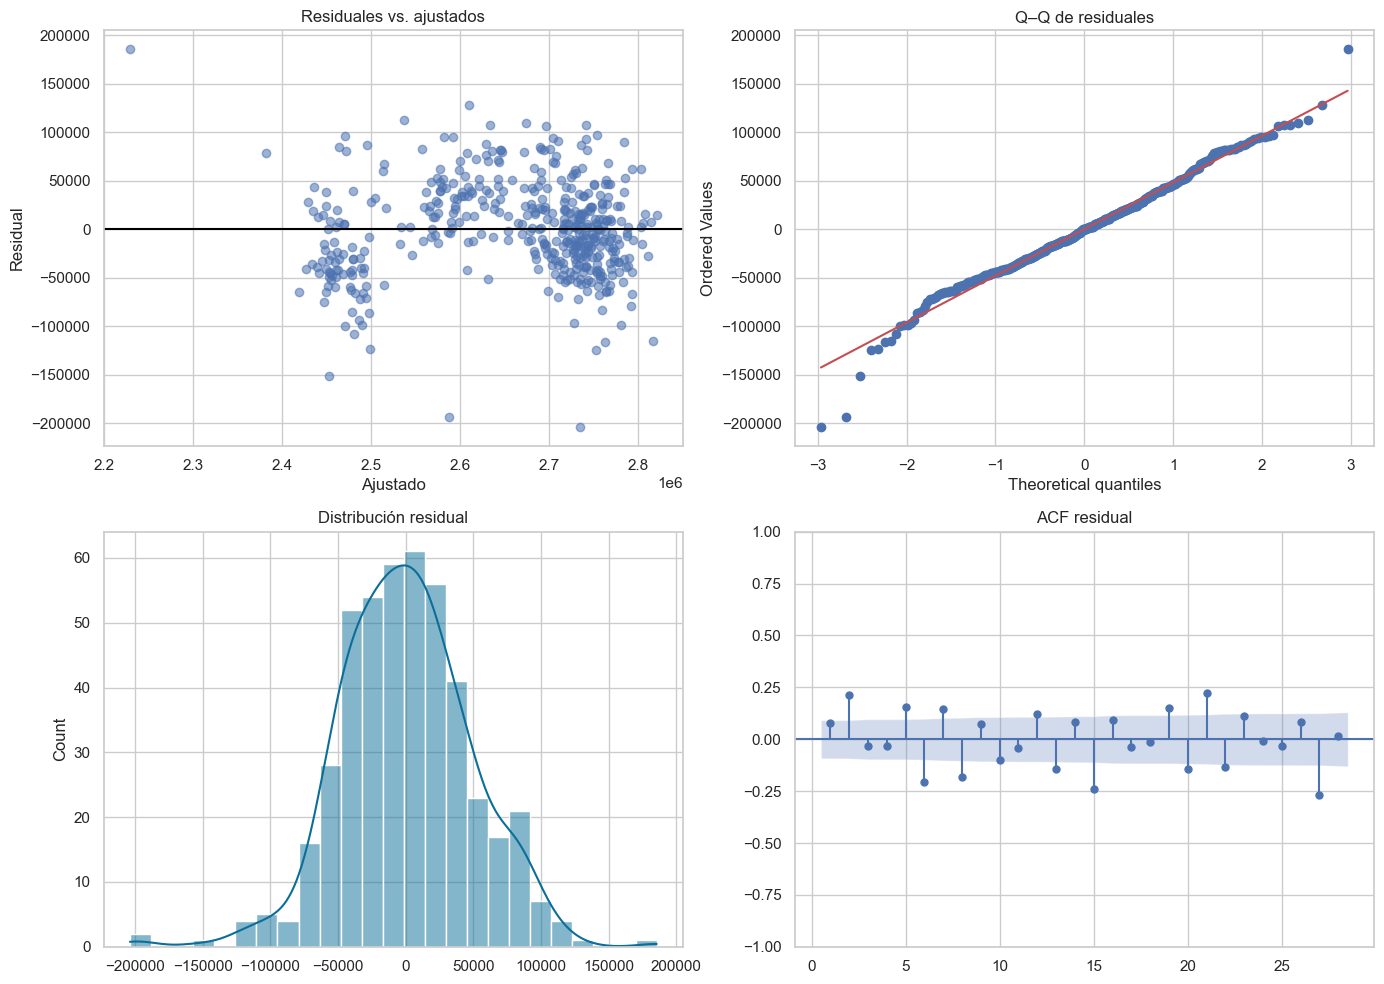

{'max_vif_finito': 14868.829734272844, 'supuestos_lineales_aprobados_en_conjunto': False}


In [17]:
# Diagnósticos estadísticos sobre el conjunto supervisado de desarrollo.
X_dev, y_dev = make_supervised(development)
X_ols = sm.add_constant(X_dev.astype(float))
ols_diagnostic_model = sm.OLS(y_dev.astype(float), X_ols).fit()
ols_fitted = pd.Series(ols_diagnostic_model.fittedvalues, index=y_dev.index)
ols_residuals = pd.Series(ols_diagnostic_model.resid, index=y_dev.index)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    vif_values = [
        variance_inflation_factor(X_dev.to_numpy(dtype=float), i)
        for i in range(X_dev.shape[1])
    ]
vif_table = pd.DataFrame({
    "variable": FEATURE_COLUMNS,
    "VIF": vif_values,
}).sort_values("VIF", ascending=False)
shapiro_stat, shapiro_p = shapiro(ols_residuals)
dw_stat = float(durbin_watson(ols_residuals))
bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(ols_residuals, X_ols)

diagnostic_table = pd.DataFrame([
    ["Shapiro–Wilk", float(shapiro_stat), float(shapiro_p), "p>0.05: no rechazar normalidad"],
    ["Durbin–Watson", dw_stat, np.nan, "aprox. 2: poca autocorrelación de orden 1"],
    ["Breusch–Pagan", float(bp_lm), float(bp_lm_p), "p>0.05: no rechazar homocedasticidad"],
], columns=["prueba", "estadistico", "p_value", "lectura"])
display(diagnostic_table)
display(vif_table.head(12))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].scatter(ols_fitted, ols_residuals, alpha=0.55)
axes[0, 0].axhline(0, color="black")
axes[0, 0].set_title("Residuales vs. ajustados")
axes[0, 0].set_xlabel("Ajustado")
axes[0, 0].set_ylabel("Residual")
stats.probplot(ols_residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Q–Q de residuales")
sns.histplot(ols_residuals, kde=True, ax=axes[1, 0], color="#0B6E99")
axes[1, 0].set_title("Distribución residual")
plot_acf(ols_residuals, lags=28, ax=axes[1, 1], zero=False)
axes[1, 1].set_title("ACF residual")
plt.tight_layout()
plt.show()

max_vif = float(vif_table["VIF"].replace([np.inf, -np.inf], np.nan).max())
linear_assumptions_ok = bool(
    shapiro_p > 0.05 and 1.5 <= dw_stat <= 2.5 and bp_lm_p > 0.05 and max_vif < 10
)
print({"max_vif_finito": max_vif, "supuestos_lineales_aprobados_en_conjunto": linear_assumptions_ok})
iteration_journal.append({
    "iteracion": "1 — Regresión lineal",
    "hipotesis": "Una relación lineal de rezagos y calendario puede superar al baseline.",
    "cambio": "Ajustar OLS y auditar VIF, normalidad, homocedasticidad e independencia.",
    "evidencia": (
        f"WAPE={ols_summary.iloc[0]['wape_promedio']:.2%}; VIF máx.={max_vif:.1f}; "
        f"Shapiro p={shapiro_p:.4f}; DW={dw_stat:.2f}; BP p={bp_lm_p:.4f}."
    ),
    "decision": "Probar Ridge para controlar colinealidad; conservar OLS como referencia interpretable.",
})


In [18]:
linear_wape = float(ols_summary.iloc[0]["wape_promedio"])
linear_reason = []
if max_vif >= 10:
    linear_reason.append(f"multicolinealidad alta, con VIF máximo de {max_vif:,.1f}")
if shapiro_p <= 0.05:
    linear_reason.append(f"residuales no normales según Shapiro–Wilk, p={shapiro_p:.4f}")
if linear_wape >= float(best_baseline["wape_promedio"]):
    linear_reason.append("ausencia de mejora frente al mejor baseline")
display(Markdown(
    f"### Conclusión de regresión lineal\n\nLa regresión lineal obtiene WAPE de **{linear_wape:.2%}**. "
    f"No se promueve como modelo del artefacto por {'; '.join(linear_reason)}. "
    "Se conserva como referencia interpretable y se prueba Ridge para estabilizar los coeficientes correlacionados."
))


### Conclusión de regresión lineal

La regresión lineal obtiene WAPE de **2.04%**. No se promueve como modelo del artefacto por multicolinealidad alta, con VIF máximo de 14,868.8; residuales no normales según Shapiro–Wilk, p=0.0004; ausencia de mejora frente al mejor baseline. Se conserva como referencia interpretable y se prueba Ridge para estabilizar los coeficientes correlacionados.

## Etapa 2 — Ridge

Ridge mantiene la forma lineal pero penaliza coeficientes grandes. Es una respuesta directa a la multicolinealidad entre rezagos y medias móviles. Se prueban pocos valores de `alpha` para observar sensibilidad; no se lanza todavía una búsqueda masiva.


,etapa,label,familia,configuracion,wape_promedio,wape_desv,mae_promedio,rmse_promedio,sesgo_abs_promedio,r2_promedio,train_mae_promedio,brecha_mae_promedio,fit_seconds
0,2_ridge,ridge_alpha_100,ridge,"{""alpha"": 100.0}",1.67%,0.32%,"44,299","54,556",0.82%,0.765,39757.698792,1.12,0.306
1,2_ridge,ridge_alpha_10,ridge,"{""alpha"": 10.0}",1.92%,0.22%,"50,881","63,237",1.42%,0.687,37283.257014,1.36,0.294
2,2_ridge,ridge_alpha_1,ridge,"{""alpha"": 1.0}",2.02%,0.22%,"53,489","66,402",1.55%,0.655,37306.927345,1.43,0.295
3,2_ridge,ridge_alpha_0.1,ridge,"{""alpha"": 0.1}",2.03%,0.22%,"53,839","66,774",1.57%,0.651,37338.474058,1.44,0.305


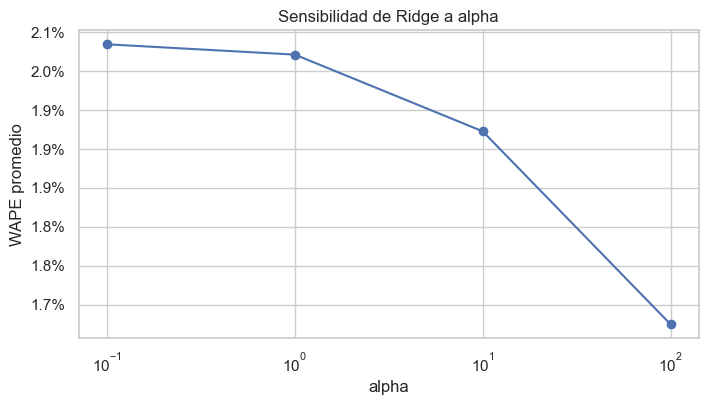

,variable,coeficiente_estandarizado,magnitud
14,es_festivo,"-36,656.9940","36,656.9940"
13,es_fin_semana,"-31,316.1257","31,316.1257"
2,lag_14,"22,797.9054","22,797.9054"
1,lag_7,"21,861.5944","21,861.5944"
3,lag_28,"19,072.8612","19,072.8612"
0,lag_1,"15,687.2527","15,687.2527"
4,media_7,"9,917.0851","9,917.0851"
6,media_28,"-8,299.7563","8,299.7563"
12,doy_cos,"5,328.7920","5,328.7920"
8,cambio_7,"-4,917.2789","4,917.2789"


In [19]:
RIDGE_ALPHAS = [0.1, 1.0, 10.0, 100.0]
ridge_labels = []
for alpha in RIDGE_ALPHAS:
    label = f"ridge_alpha_{alpha:g}"
    ridge_labels.append(label)
    evaluate_candidate("2_ridge", label, "ridge", {"alpha": alpha})

ridge_summary = summarize(ridge_labels)
display(ridge_summary.style.format({
    "wape_promedio": "{:.2%}", "wape_desv": "{:.2%}", "mae_promedio": "{:,.0f}",
    "rmse_promedio": "{:,.0f}", "sesgo_abs_promedio": "{:.2%}", "r2_promedio": "{:.3f}",
    "brecha_mae_promedio": "{:.2f}", "fit_seconds": "{:.3f}",
}))
best_ridge = ridge_summary.iloc[0]

fig, ax = plt.subplots(figsize=(8, 4))
ridge_plot = ridge_summary.assign(alpha=ridge_summary["label"].str.replace("ridge_alpha_", "").astype(float)).sort_values("alpha")
ax.semilogx(ridge_plot["alpha"], ridge_plot["wape_promedio"], marker="o")
ax.set_title("Sensibilidad de Ridge a alpha")
ax.set_xlabel("alpha")
ax.set_ylabel("WAPE promedio")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.1%}")
plt.show()

best_ridge_info = model_registry[best_ridge["label"]]
ridge_model = build_estimator(best_ridge_info["family"], best_ridge_info["params"])
ridge_model.fit(X_dev, y_dev)
ridge_coefficients = pd.DataFrame({
    "variable": FEATURE_COLUMNS,
    "coeficiente_estandarizado": ridge_model.named_steps["model"].coef_,
}).assign(magnitud=lambda frame: frame["coeficiente_estandarizado"].abs()).sort_values("magnitud", ascending=False)
display(ridge_coefficients.head(12))

iteration_journal.append({
    "iteracion": "2 — Ridge",
    "hipotesis": "La regularización estabiliza variables correlacionadas sin perder trazabilidad.",
    "cambio": "Comparar cuatro valores de alpha con los mismos pliegues temporales.",
    "evidencia": f"Mejor {best_ridge['label']}; WAPE={best_ridge['wape_promedio']:.2%}; desviación={best_ridge['wape_desv']:.2%}.",
    "decision": "Probar un árbol únicamente para comprobar si relaciones no lineales aportan una mejora material.",
})


In [20]:
ridge_gain = float(best_baseline["wape_promedio"] - best_ridge["wape_promedio"])
display(Markdown(
    f"### Conclusión de Ridge\n\nLa mejor configuración es **{best_ridge['label']}**, con WAPE de **{best_ridge['wape_promedio']:.2%}**. "
    f"Mejora el baseline en {ridge_gain * 100:.2f} puntos porcentuales y controla la inestabilidad de coeficientes, por lo que queda como candidato lineal. "
    "Se continúa con un árbol para comprobar si la no linealidad produce una mejora material."
))


### Conclusión de Ridge

La mejor configuración es **ridge_alpha_100**, con WAPE de **1.67%**. Mejora el baseline en 0.28 puntos porcentuales y controla la inestabilidad de coeficientes, por lo que queda como candidato lineal. Se continúa con un árbol para comprobar si la no linealidad produce una mejora material.

## Etapa 3 — Árbol de decisión

Un árbol individual permite reglas no lineales e interacciones, y todavía puede explicarse. Su riesgo principal es el sobreajuste: profundidad alta puede memorizar el entrenamiento. Por eso se varían solo `max_depth` y `min_samples_leaf`, y se observa la brecha entre MAE de entrenamiento y validación.


,etapa,label,familia,configuracion,wape_promedio,wape_desv,mae_promedio,rmse_promedio,sesgo_abs_promedio,r2_promedio,train_mae_promedio,brecha_mae_promedio,fit_seconds
0,3_arbol,arbol_d8_leaf10,arbol,"{""max_depth"": 8, ""min_samples_leaf"": 10}",1.37%,0.56%,"36,222","43,945",0.67%,0.841,23335.021579,1.55,0.300
1,3_arbol,arbol_d5_leaf10,arbol,"{""max_depth"": 5, ""min_samples_leaf"": 10}",1.51%,0.47%,"39,810","47,613",0.82%,0.818,26528.014545,1.50,0.317
2,3_arbol,arbol_d5_leaf5,arbol,"{""max_depth"": 5, ""min_samples_leaf"": 5}",1.54%,0.39%,"40,654","50,589",0.92%,0.794,25339.999697,1.60,0.305
3,3_arbol,arbol_d3_leaf5,arbol,"{""max_depth"": 3, ""min_samples_leaf"": 5}",1.60%,0.65%,"42,271","49,187",0.81%,0.801,36254.917594,1.17,0.311
4,3_arbol,arbol_d3_leaf10,arbol,"{""max_depth"": 3, ""min_samples_leaf"": 10}",1.61%,0.67%,"42,595","49,963",0.82%,0.795,37026.478683,1.15,0.311
5,3_arbol,arbol_dnone_leaf10,arbol,"{""max_depth"": null, ""min_samples_leaf"": 10}",1.61%,0.21%,"42,716","52,305",0.58%,0.786,22658.574227,1.88,0.310
6,3_arbol,arbol_dnone_leaf5,arbol,"{""max_depth"": null, ""min_samples_leaf"": 5}",1.79%,0.61%,"47,331","56,947",0.77%,0.728,17065.538205,2.77,0.318
7,3_arbol,arbol_d8_leaf5,arbol,"{""max_depth"": 8, ""min_samples_leaf"": 5}",1.82%,0.13%,"48,107","59,374",1.13%,0.723,19751.942799,2.44,0.315


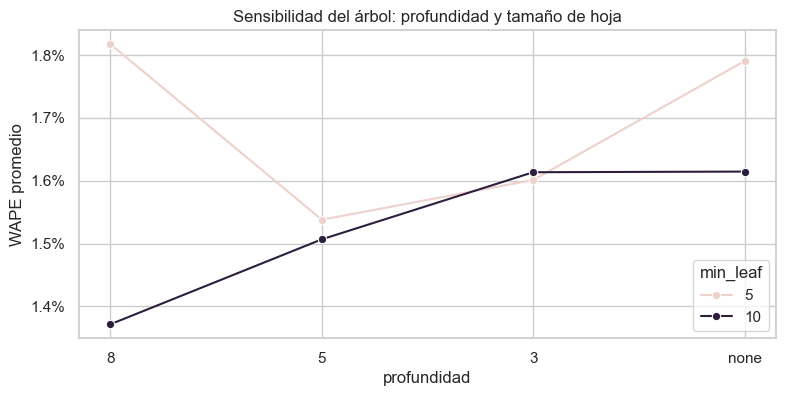

,variable,importancia
1,lag_7,0.5699
13,es_fin_semana,0.2005
14,es_festivo,0.1398
0,lag_1,0.0743
4,media_7,0.0026
15,tendencia,0.0025
3,lag_28,0.0025
7,desv_28,0.0024
12,doy_cos,0.0022
6,media_28,0.0013


In [21]:
TREE_DEPTHS = [3, 5, 8, None]
TREE_MIN_LEAVES = [5, 10]
tree_labels = []
for depth in TREE_DEPTHS:
    for min_leaf in TREE_MIN_LEAVES:
        depth_label = "none" if depth is None else str(depth)
        label = f"arbol_d{depth_label}_leaf{min_leaf}"
        tree_labels.append(label)
        evaluate_candidate(
            "3_arbol", label, "arbol",
            {"max_depth": depth, "min_samples_leaf": min_leaf},
        )

tree_summary = summarize(tree_labels)
display(tree_summary.style.format({
    "wape_promedio": "{:.2%}", "wape_desv": "{:.2%}", "mae_promedio": "{:,.0f}",
    "rmse_promedio": "{:,.0f}", "sesgo_abs_promedio": "{:.2%}", "r2_promedio": "{:.3f}",
    "brecha_mae_promedio": "{:.2f}", "fit_seconds": "{:.3f}",
}))
best_tree = tree_summary.iloc[0]

tree_plot = tree_summary.copy()
tree_plot["profundidad"] = tree_plot["label"].str.extract(r"arbol_d([^_]+)")[0]
tree_plot["min_leaf"] = tree_plot["label"].str.extract(r"leaf(\d+)")[0].astype(int)
fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=tree_plot, x="profundidad", y="wape_promedio", hue="min_leaf", marker="o", ax=ax)
ax.set_title("Sensibilidad del árbol: profundidad y tamaño de hoja")
ax.set_ylabel("WAPE promedio")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.1%}")
plt.show()

tree_info = model_registry[best_tree["label"]]
tree_model = build_estimator(tree_info["family"], tree_info["params"])
tree_model.fit(X_dev, y_dev)
tree_importance = pd.DataFrame({
    "variable": FEATURE_COLUMNS, "importancia": tree_model.feature_importances_,
}).sort_values("importancia", ascending=False)
display(tree_importance.head(12))

iteration_journal.append({
    "iteracion": "3 — Árbol",
    "hipotesis": "Reglas no lineales pueden capturar interacciones que Ridge no representa.",
    "cambio": "Variar profundidad y mínimo de observaciones por hoja.",
    "evidencia": (
        f"Mejor {best_tree['label']}; WAPE={best_tree['wape_promedio']:.2%}; "
        f"brecha MAE val/train={best_tree['brecha_mae_promedio']:.2f}x."
    ),
    "decision": "Probar Random Forest para reducir la varianza del árbol y contrastar estabilidad.",
})


In [22]:
tree_gain = float(best_ridge["wape_promedio"] - best_tree["wape_promedio"])
display(Markdown(
    f"### Conclusión del árbol\n\nEl árbol **{best_tree['label']}** alcanza WAPE de **{best_tree['wape_promedio']:.2%}** y mejora Ridge en {tree_gain * 100:.2f} puntos porcentuales. "
    f"La brecha validación/entrenamiento es {best_tree['brecha_mae_promedio']:.2f} veces. "
    "Se mantiene como candidato interpretable, pero se prueba Random Forest para verificar si el promedio de árboles reduce la varianza."
))


### Conclusión del árbol

El árbol **arbol_d8_leaf10** alcanza WAPE de **1.37%** y mejora Ridge en 0.30 puntos porcentuales. La brecha validación/entrenamiento es 1.55 veces. Se mantiene como candidato interpretable, pero se prueba Random Forest para verificar si el promedio de árboles reduce la varianza.

## Etapa 4 — Random Forest

Random Forest promedia árboles entrenados con muestras y variables aleatorias. Aumenta costo y reduce interpretabilidad frente al árbol individual, por lo que solo se justifica si mejora desempeño o estabilidad. Se mantiene una grilla pequeña y legible.


In [23]:
RF_DEPTHS = [6, 10, None]
RF_MIN_LEAVES = [3, 8]
rf_labels = []
for depth in RF_DEPTHS:
    for min_leaf in RF_MIN_LEAVES:
        depth_label = "none" if depth is None else str(depth)
        label = f"rf_d{depth_label}_leaf{min_leaf}"
        rf_labels.append(label)
        evaluate_candidate(
            "4_random_forest", label, "random_forest",
            {"n_estimators": 200, "max_depth": depth, "min_samples_leaf": min_leaf, "max_features": 0.8},
        )

rf_summary = summarize(rf_labels)
display(rf_summary.style.format({
    "wape_promedio": "{:.2%}", "wape_desv": "{:.2%}", "mae_promedio": "{:,.0f}",
    "rmse_promedio": "{:,.0f}", "sesgo_abs_promedio": "{:.2%}", "r2_promedio": "{:.3f}",
    "brecha_mae_promedio": "{:.2f}", "fit_seconds": "{:.3f}",
}))
best_rf = rf_summary.iloc[0]

iteration_journal.append({
    "iteracion": "4 — Random Forest",
    "hipotesis": "Promediar árboles reduce la inestabilidad del árbol individual.",
    "cambio": "Entrenar 200 árboles con tres profundidades y dos tamaños mínimos de hoja.",
    "evidencia": (
        f"Mejor {best_rf['label']}; WAPE={best_rf['wape_promedio']:.2%}; "
        f"desviación={best_rf['wape_desv']:.2%}; tiempo={best_rf['fit_seconds']:.2f}s."
    ),
    "decision": "Probar Extra Trees como última complejidad y exigir mejora medible.",
})


,etapa,label,familia,configuracion,wape_promedio,wape_desv,mae_promedio,rmse_promedio,sesgo_abs_promedio,r2_promedio,train_mae_promedio,brecha_mae_promedio,fit_seconds
0,4_random_forest,rf_d6_leaf8,random_forest,"{""max_depth"": 6, ""max_features"": 0.8, ""min_samples_leaf"": 8, ""n_estimators"": 200}",1.36%,0.52%,"35,925","43,061",0.58%,0.848,24133.074967,1.49,1.189
1,4_random_forest,rf_d10_leaf8,random_forest,"{""max_depth"": 10, ""max_features"": 0.8, ""min_samples_leaf"": 8, ""n_estimators"": 200}",1.36%,0.51%,"35,979","43,890",0.63%,0.842,22484.828677,1.61,1.253
2,4_random_forest,rf_dnone_leaf8,random_forest,"{""max_depth"": null, ""max_features"": 0.8, ""min_samples_leaf"": 8, ""n_estimators"": 200}",1.37%,0.51%,"36,057","44,110",0.64%,0.841,22438.358622,1.61,1.277
3,4_random_forest,rf_d6_leaf3,random_forest,"{""max_depth"": 6, ""max_features"": 0.8, ""min_samples_leaf"": 3, ""n_estimators"": 200}",1.45%,0.54%,"38,209","45,603",0.64%,0.828,19881.642422,1.92,1.186
4,4_random_forest,rf_dnone_leaf3,random_forest,"{""max_depth"": null, ""max_features"": 0.8, ""min_samples_leaf"": 3, ""n_estimators"": 200}",1.45%,0.50%,"38,315","45,785",0.54%,0.829,14013.193555,2.73,1.260
5,4_random_forest,rf_d10_leaf3,random_forest,"{""max_depth"": 10, ""max_features"": 0.8, ""min_samples_leaf"": 3, ""n_estimators"": 200}",1.46%,0.52%,"38,618","46,308",0.53%,0.824,15136.190132,2.55,1.224


In [24]:
rf_gain = float(best_tree["wape_promedio"] - best_rf["wape_promedio"])
display(Markdown(
    f"### Conclusión de Random Forest\n\nLa mejor configuración **{best_rf['label']}** obtiene WAPE de **{best_rf['wape_promedio']:.2%}** y mejora el árbol en {rf_gain * 100:.2f} puntos porcentuales. "
    "La mejora justifica conservar el ensamble para la comparación final. Extra Trees se evalúa como último escalón y deberá superar este resultado."
))


### Conclusión de Random Forest

La mejor configuración **rf_d6_leaf8** obtiene WAPE de **1.36%** y mejora el árbol en 0.01 puntos porcentuales. La mejora justifica conservar el ensamble para la comparación final. Extra Trees se evalúa como último escalón y deberá superar este resultado.

## Etapa 5 — Extra Trees

Extra Trees es el último escalón, no el punto de partida. Además de variar muestras y variables, prueba cortes más aleatorios dentro de los árboles. Puede disminuir varianza y entrenar rápido, pero sus decisiones son menos fáciles de explicar globalmente. Se conserva solo si la evidencia supera a Random Forest.


In [25]:
ET_DEPTHS = [8, None]
ET_MIN_LEAVES = [3, 8, 12]
et_labels = []
for depth in ET_DEPTHS:
    for min_leaf in ET_MIN_LEAVES:
        depth_label = "none" if depth is None else str(depth)
        label = f"et_d{depth_label}_leaf{min_leaf}"
        et_labels.append(label)
        evaluate_candidate(
            "5_extra_trees", label, "extra_trees",
            {"n_estimators": 250, "max_depth": depth, "min_samples_leaf": min_leaf, "max_features": 0.8},
        )

et_summary = summarize(et_labels)
display(et_summary.style.format({
    "wape_promedio": "{:.2%}", "wape_desv": "{:.2%}", "mae_promedio": "{:,.0f}",
    "rmse_promedio": "{:,.0f}", "sesgo_abs_promedio": "{:.2%}", "r2_promedio": "{:.3f}",
    "brecha_mae_promedio": "{:.2f}", "fit_seconds": "{:.3f}",
}))
best_et = et_summary.iloc[0]

iteration_journal.append({
    "iteracion": "5 — Extra Trees",
    "hipotesis": "Cortes más aleatorios reducen varianza sin perder desempeño.",
    "cambio": "Comparar profundidad y tamaño de hoja con 250 árboles.",
    "evidencia": (
        f"Mejor {best_et['label']}; WAPE={best_et['wape_promedio']:.2%}; "
        f"desviación={best_et['wape_desv']:.2%}; tiempo={best_et['fit_seconds']:.2f}s."
    ),
    "decision": "Comparar todas las familias por desempeño, estabilidad, sesgo, overfitting, tiempo e interpretabilidad.",
})


,etapa,label,familia,configuracion,wape_promedio,wape_desv,mae_promedio,rmse_promedio,sesgo_abs_promedio,r2_promedio,train_mae_promedio,brecha_mae_promedio,fit_seconds
0,5_extra_trees,et_d8_leaf12,extra_trees,"{""max_depth"": 8, ""max_features"": 0.8, ""min_samples_leaf"": 12, ""n_estimators"": 250}",1.43%,0.53%,"37,796","44,186",0.64%,0.839,25592.884980,1.48,1.648
1,5_extra_trees,et_dnone_leaf12,extra_trees,"{""max_depth"": null, ""max_features"": 0.8, ""min_samples_leaf"": 12, ""n_estimators"": 250}",1.44%,0.53%,"37,917","44,328",0.62%,0.838,25277.591894,1.50,0.975
2,5_extra_trees,et_d8_leaf8,extra_trees,"{""max_depth"": 8, ""max_features"": 0.8, ""min_samples_leaf"": 8, ""n_estimators"": 250}",1.47%,0.53%,"38,867","45,453",0.68%,0.831,22701.613020,1.71,1.104
3,5_extra_trees,et_dnone_leaf8,extra_trees,"{""max_depth"": null, ""max_features"": 0.8, ""min_samples_leaf"": 8, ""n_estimators"": 250}",1.48%,0.52%,"39,002","45,625",0.70%,0.829,21988.269119,1.78,0.975
4,5_extra_trees,et_d8_leaf3,extra_trees,"{""max_depth"": 8, ""max_features"": 0.8, ""min_samples_leaf"": 3, ""n_estimators"": 250}",1.49%,0.52%,"39,491","46,775",0.76%,0.820,17095.999995,2.30,1.174
5,5_extra_trees,et_dnone_leaf3,extra_trees,"{""max_depth"": null, ""max_features"": 0.8, ""min_samples_leaf"": 3, ""n_estimators"": 250}",1.51%,0.44%,"39,851","48,266",0.78%,0.812,12638.395547,3.16,1.421


In [26]:
et_gain = float(best_rf["wape_promedio"] - best_et["wape_promedio"])
display(Markdown(
    f"### Conclusión de Extra Trees\n\nLa configuración **{best_et['label']}** logra WAPE de **{best_et['wape_promedio']:.2%}** y cambia el resultado de Random Forest en {et_gain * 100:.2f} puntos porcentuales. "
    "Se conserva como champion provisional. Los dos challengers siguientes deben demostrar una mejora consistente para justificar un cambio."
))


### Conclusión de Extra Trees

La configuración **et_d8_leaf12** logra WAPE de **1.43%** y cambia el resultado de Random Forest en -0.07 puntos porcentuales. Se conserva como champion provisional. Los dos challengers siguientes deben demostrar una mejora consistente para justificar un cambio.

## Etapa 6 — HistGradientBoosting

El boosting corrige errores de forma secuencial y puede representar relaciones no lineales con menos árboles que un ensamble por bagging. Se utiliza la implementación nativa de `scikit-learn` para evitar una dependencia adicional en Colab y en Docker. La grilla permanece pequeña y se define antes de observar la prueba final.


In [27]:
HGB_CONFIGS = [
    {"learning_rate": 0.03, "max_iter": 250, "max_leaf_nodes": 15, "min_samples_leaf": 10, "l2_regularization": 0.1},
    {"learning_rate": 0.05, "max_iter": 200, "max_leaf_nodes": 15, "min_samples_leaf": 15, "l2_regularization": 1.0},
    {"learning_rate": 0.05, "max_iter": 250, "max_leaf_nodes": 31, "min_samples_leaf": 15, "l2_regularization": 1.0},
]
hgb_labels = []
for index, params in enumerate(HGB_CONFIGS, 1):
    label = f"hgb_{index}"
    hgb_labels.append(label)
    evaluate_candidate("6_hist_gradient_boosting", label, "hist_gradient_boosting", params)

hgb_summary = summarize(hgb_labels)
display(hgb_summary.style.format({
    "wape_promedio": "{:.2%}", "wape_desv": "{:.2%}", "mae_promedio": "{:,.0f}",
    "rmse_promedio": "{:,.0f}", "sesgo_abs_promedio": "{:.2%}", "r2_promedio": "{:.3f}",
    "brecha_mae_promedio": "{:.2f}", "fit_seconds": "{:.3f}",
}))
best_hgb = hgb_summary.iloc[0]

iteration_journal.append({
    "iteracion": "6 — HistGradientBoosting",
    "hipotesis": "Corregir errores secuencialmente puede mejorar la generalización sin ampliar demasiado la operación.",
    "cambio": "Evaluar tres configuraciones predefinidas de tasa, hojas y regularización.",
    "evidencia": f"Mejor {best_hgb['label']}; WAPE={best_hgb['wape_promedio']:.2%}; desviación={best_hgb['wape_desv']:.2%}.",
    "decision": "Conservar únicamente si la mejora se repite entre pliegues y supera la regla de promoción.",
})


,etapa,label,familia,configuracion,wape_promedio,wape_desv,mae_promedio,rmse_promedio,sesgo_abs_promedio,r2_promedio,train_mae_promedio,brecha_mae_promedio,fit_seconds
0,6_hist_gradient_boosting,hgb_2,hist_gradient_boosting,"{""l2_regularization"": 1.0, ""learning_rate"": 0.05, ""max_iter"": 200, ""max_leaf_nodes"": 15, ""min_samples_leaf"": 15}",1.51%,0.50%,"39,834","47,838",0.69%,0.814,7847.570575,5.02,1.134
1,6_hist_gradient_boosting,hgb_1,hist_gradient_boosting,"{""l2_regularization"": 0.1, ""learning_rate"": 0.03, ""max_iter"": 250, ""max_leaf_nodes"": 15, ""min_samples_leaf"": 10}",1.57%,0.57%,"41,606","50,448",0.76%,0.793,9527.259264,4.34,3.461
2,6_hist_gradient_boosting,hgb_3,hist_gradient_boosting,"{""l2_regularization"": 1.0, ""learning_rate"": 0.05, ""max_iter"": 250, ""max_leaf_nodes"": 31, ""min_samples_leaf"": 15}",1.66%,0.58%,"43,835","52,797",0.75%,0.775,4635.372435,9.45,1.606


In [28]:
hgb_gain = float(best_et["wape_promedio"] - best_hgb["wape_promedio"])
display(Markdown(
    f"### Conclusión de boosting\n\nLa mejor configuración obtiene WAPE de **{best_hgb['wape_promedio']:.2%}** y cambia Extra Trees en {hgb_gain * 100:.2f} puntos porcentuales. "
    "El resultado lo incorpora a la comparación final, pero todavía no autoriza reemplazar el champion del artefacto."
))


### Conclusión de boosting

La mejor configuración obtiene WAPE de **1.51%** y cambia Extra Trees en -0.08 puntos porcentuales. El resultado lo incorpora a la comparación final, pero todavía no autoriza reemplazar el champion del artefacto.

## Etapa 7 — Holt-Winters

Holt-Winters funciona como challenger temporal explícito: modela nivel, tendencia y estacionalidad semanal sin utilizar la matriz de rezagos del aprendizaje supervisado. Su inclusión permite comprobar si la complejidad de los ensambles realmente aporta valor frente a una estructura temporal reconocible.


In [29]:
HW_CONFIGS = [
    {"trend": None, "damped_trend": False, "seasonal": "add", "seasonal_periods": 7},
    {"trend": "add", "damped_trend": True, "seasonal": "add", "seasonal_periods": 7},
]
hw_labels = []
for index, params in enumerate(HW_CONFIGS, 1):
    label = f"holt_winters_{index}"
    hw_labels.append(label)
    evaluate_candidate("7_holt_winters", label, "holt_winters", params)

hw_summary = summarize(hw_labels)
display(hw_summary.style.format({
    "wape_promedio": "{:.2%}", "wape_desv": "{:.2%}", "mae_promedio": "{:,.0f}",
    "rmse_promedio": "{:,.0f}", "sesgo_abs_promedio": "{:.2%}", "r2_promedio": "{:.3f}",
    "brecha_mae_promedio": "{:.2f}", "fit_seconds": "{:.3f}",
}))
best_hw = hw_summary.iloc[0]

iteration_journal.append({
    "iteracion": "7 — Holt-Winters",
    "hipotesis": "Una tendencia con estacionalidad semanal explícita puede competir con los modelos supervisados.",
    "cambio": "Comparar nivel estacional y tendencia aditiva amortiguada bajo los mismos pliegues.",
    "evidencia": f"Mejor {best_hw['label']}; WAPE={best_hw['wape_promedio']:.2%}; desviación={best_hw['wape_desv']:.2%}.",
    "decision": "Llevar a selección como alternativa temporal interpretable.",
})


C:\Users\DARLAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DARLAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DARLAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DARLAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


C:\Users\DARLAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DARLAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


,etapa,label,familia,configuracion,wape_promedio,wape_desv,mae_promedio,rmse_promedio,sesgo_abs_promedio,r2_promedio,train_mae_promedio,brecha_mae_promedio,fit_seconds
0,7_holt_winters,holt_winters_2,holt_winters,"{""damped_trend"": true, ""seasonal"": ""add"", ""seasonal_periods"": 7, ""trend"": ""add""}",1.59%,0.37%,"42,152","57,685",0.73%,0.728,40546.044577,1.04,0.399
1,7_holt_winters,holt_winters_1,holt_winters,"{""damped_trend"": false, ""seasonal"": ""add"", ""seasonal_periods"": 7, ""trend"": null}",1.61%,0.29%,"42,532","58,993",0.78%,0.718,39623.476770,1.08,0.124


In [30]:
hw_gain = float(best_et["wape_promedio"] - best_hw["wape_promedio"])
display(Markdown(
    f"### Conclusión del modelo temporal\n\nLa mejor configuración obtiene WAPE de **{best_hw['wape_promedio']:.2%}** y cambia Extra Trees en {hw_gain * 100:.2f} puntos porcentuales. "
    "Holt-Winters avanza a la comparación final como control temporal; su promoción también exige evidencia nueva y consistente."
))


### Conclusión del modelo temporal

La mejor configuración obtiene WAPE de **1.59%** y cambia Extra Trees en -0.16 puntos porcentuales. Holt-Winters avanza a la comparación final como control temporal; su promoción también exige evidencia nueva y consistente.

# Parte V — Comparación sistemática y selección

Para evitar seleccionar por una única cifra, se comparan seis criterios:

1. WAPE promedio;
2. estabilidad entre pliegues;
3. sesgo absoluto;
4. brecha validación/entrenamiento;
5. tiempo de ajuste;
6. interpretabilidad relativa.

La regla principal sigue siendo WAPE. Si dos alternativas quedan a menos de 0,20 puntos porcentuales, se prefiere la más interpretable y estable. Extra Trees continúa como champion operativo provisional hasta que un challenger cumpla la regla de promoción con ventanas posteriores a 2025.


In [31]:
all_summary = summarize()
best_by_family = (
    all_summary.sort_values(["wape_promedio", "rmse_promedio"])
    .groupby("familia", as_index=False)
    .first()
)
interpretability = {
    "baseline": 5, "regresion_lineal": 5, "ridge": 4, "arbol": 4,
    "random_forest": 2, "extra_trees": 2, "hist_gradient_boosting": 2, "holt_winters": 4,
}
complexity = {
    "baseline": 1, "regresion_lineal": 2, "ridge": 2, "arbol": 3,
    "random_forest": 4, "extra_trees": 5, "hist_gradient_boosting": 5, "holt_winters": 3,
}
best_by_family["interpretabilidad_1_5"] = best_by_family["familia"].map(interpretability)
best_by_family["complejidad_1_5"] = best_by_family["familia"].map(complexity)
best_by_family["mejora_vs_baseline_pct"] = (
    (best_baseline["wape_promedio"] - best_by_family["wape_promedio"])
    / best_baseline["wape_promedio"]
)
best_by_family = best_by_family.sort_values("wape_promedio").reset_index(drop=True)
display(best_by_family[[
    "familia", "label", "wape_promedio", "wape_desv", "rmse_promedio",
    "sesgo_abs_promedio", "brecha_mae_promedio", "fit_seconds",
    "interpretabilidad_1_5", "complejidad_1_5", "mejora_vs_baseline_pct",
]].style.format({
    "wape_promedio": "{:.2%}", "wape_desv": "{:.2%}", "rmse_promedio": "{:,.0f}",
    "sesgo_abs_promedio": "{:.2%}", "brecha_mae_promedio": "{:.2f}",
    "fit_seconds": "{:.2f}", "mejora_vs_baseline_pct": "{:.1%}",
}))

learned_candidates = best_by_family[best_by_family["familia"].ne("baseline")].copy()
best_wape = learned_candidates["wape_promedio"].min()
eligible = learned_candidates[learned_candidates["wape_promedio"] <= best_wape + 0.002].copy()
selected_row = eligible.sort_values(
    ["interpretabilidad_1_5", "wape_desv", "wape_promedio"],
    ascending=[False, True, True],
).iloc[0]
SELECTED_LABEL = selected_row["label"]
SELECTED_FAMILY = selected_row["familia"]
SELECTED_PARAMS = model_registry[SELECTED_LABEL]["params"]
print("Candidato seleccionado con regla desempeño + parsimonia:", SELECTED_LABEL, SELECTED_PARAMS)


,familia,label,wape_promedio,wape_desv,rmse_promedio,sesgo_abs_promedio,brecha_mae_promedio,fit_seconds,interpretabilidad_1_5,complejidad_1_5,mejora_vs_baseline_pct
0,random_forest,rf_d6_leaf8,1.36%,0.52%,"43,061",0.58%,1.49,1.19,2,4,30.5%
1,arbol,arbol_d8_leaf10,1.37%,0.56%,"43,945",0.67%,1.55,0.30,4,3,30.0%
2,extra_trees,et_d8_leaf12,1.43%,0.53%,"44,186",0.64%,1.48,1.65,2,5,26.9%
3,hist_gradient_boosting,hgb_2,1.51%,0.50%,"47,838",0.69%,5.02,1.13,2,5,23.0%
4,holt_winters,holt_winters_2,1.59%,0.37%,"57,685",0.73%,1.04,0.40,4,3,18.6%
5,ridge,ridge_alpha_100,1.67%,0.32%,"54,556",0.82%,1.12,0.31,4,2,14.5%
6,baseline,estacional_7,1.96%,0.58%,"70,099",1.07%,nan,0.00,5,1,0.0%
7,regresion_lineal,regresion_lineal,2.04%,0.22%,"66,816",1.57%,1.44,0.30,5,2,-4.0%


Candidato seleccionado con regla desempeño + parsimonia: arbol_d8_leaf10 {'max_depth': 8, 'min_samples_leaf': 10}


,dias_historia,filas_entrenamiento,wape_train,wape_validacion
0,120,92,1.30%,3.61%
1,160,132,1.63%,2.95%
2,200,172,1.62%,2.82%
3,457,429,0.89%,1.96%


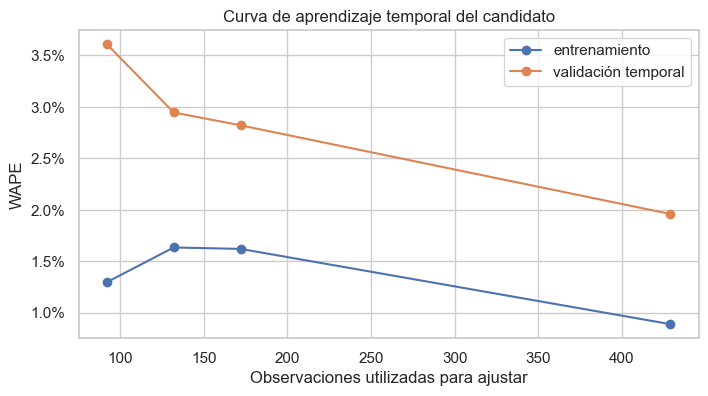

In [32]:
learning_validation = development.iloc[-CV_HORIZON_DAYS:]
pre_validation = development.iloc[:-CV_HORIZON_DAYS]
window_options = sorted(set([120, 160, 200, len(pre_validation)]))
learning_rows = []
for window in window_options:
    train_subset = pre_validation.iloc[-window:]
    estimator, _, y_subset, train_pred = fit_forecaster(SELECTED_FAMILY, SELECTED_PARAMS, train_subset)
    validation_pred = forecast_forecaster(estimator, SELECTED_FAMILY, train_subset, learning_validation.index)
    learning_rows.append({
        "dias_historia": len(train_subset),
        "filas_entrenamiento": len(y_subset),
        "wape_train": regression_metrics(y_subset, train_pred)["wape"],
        "wape_validacion": regression_metrics(learning_validation, validation_pred)["wape"],
    })
learning_curve = pd.DataFrame(learning_rows)
display(learning_curve.style.format({"wape_train": "{:.2%}", "wape_validacion": "{:.2%}"}))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(learning_curve["filas_entrenamiento"], learning_curve["wape_train"], marker="o", label="entrenamiento")
ax.plot(learning_curve["filas_entrenamiento"], learning_curve["wape_validacion"], marker="o", label="validación temporal")
ax.set_title("Curva de aprendizaje temporal del candidato")
ax.set_xlabel("Observaciones utilizadas para ajustar")
ax.set_ylabel("WAPE")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.1%}")
ax.legend()
plt.show()


In [33]:
display(Markdown(
    f"### Conclusión de selección\n\nLa regla conjunta propone **{SELECTED_LABEL}** de la familia **{SELECTED_FAMILY}**, con WAPE de validación de **{selected_row['wape_promedio']:.2%}**. "
    f"La prueba final entre **{OOT_START.date()}** y **{OOT_END.date()}** permanece aislada y no se utilizará para volver a escoger hiperparámetros. "
    "La propuesta aún debe pasar la regla champion–challenger antes de modificar el artefacto Docker."
))


### Conclusión de selección

La regla conjunta propone **arbol_d8_leaf10** de la familia **arbol**, con WAPE de validación de **1.37%**. La prueba final entre **2026-07-01** y **2026-07-31** permanece aislada y no se utilizará para volver a escoger hiperparámetros. La propuesta aún debe pasar la regla champion–challenger antes de modificar el artefacto Docker.

# Parte VI — Calibración separada y prueba final móvil

El último mes completo disponible se reserva como prueba final. Los dos meses inmediatamente anteriores calibran el error y todo lo previo se utiliza para desarrollo y selección. Cuando se agreguen nuevas observaciones, los tres bloques avanzan en el tiempo de forma automática.

La prueba final confirma o cuestiona al candidato, pero no se usa para cambiar configuraciones. Un challenger diferente de Extra Trees solo queda listo para revisión del Docker si acumula al menos tres ventanas posteriores a 2025 y mejora al champion por el margen predefinido.


In [34]:
calibration_train = y.loc[:DEVELOPMENT_END]
calibration_actual = y.loc[CALIBRATION_START:CALIBRATION_END]
calibration_model, _, _, _ = fit_forecaster(SELECTED_FAMILY, SELECTED_PARAMS, calibration_train)
calibration_pred = forecast_forecaster(
    calibration_model, SELECTED_FAMILY, calibration_train, calibration_actual.index
)
calibration_metrics = regression_metrics(calibration_actual, calibration_pred)

final_train = y.loc[:CALIBRATION_END]
oot_actual = y.loc[OOT_START:OOT_END]
oot_predictions = pd.DataFrame({"real": oot_actual})
oot_metric_rows = []
final_model = X_final = y_final = None
for _, family_row in best_by_family.loc[best_by_family["familia"].ne("baseline")].iterrows():
    family = family_row["familia"]
    params = json.loads(family_row["configuracion"])
    fitted, X_fit, y_fit, _ = fit_forecaster(family, params, final_train)
    pred = forecast_forecaster(fitted, family, final_train, oot_actual.index)
    oot_predictions[f"modelo_{family}"] = pred
    oot_metric_rows.append({"alternativa": f"modelo_{family}", **regression_metrics(oot_actual, pred)})
    if family == SELECTED_FAMILY:
        final_model, X_final, y_final = fitted, X_fit, y_fit

selected_pred = oot_predictions[f"modelo_{SELECTED_FAMILY}"]
for baseline in BASELINES:
    pred = baseline_forecast(baseline, final_train, oot_actual.index)
    oot_predictions[baseline] = pred
    oot_metric_rows.append({"alternativa": baseline, **regression_metrics(oot_actual, pred)})
oot_metrics = pd.DataFrame(oot_metric_rows).sort_values(["wape", "rmse"]).reset_index(drop=True)

display(pd.DataFrame([calibration_metrics], index=["calibracion"]).style.format({
    "wape": "{:.2%}", "mae": "{:,.0f}", "rmse": "{:,.0f}", "sesgo_pct": "{:.2%}", "r2": "{:.3f}",
}))
display(oot_metrics.style.format({
    "wape": "{:.2%}", "mae": "{:,.0f}", "rmse": "{:,.0f}", "sesgo_pct": "{:.2%}", "r2": "{:.3f}",
}))


C:\Users\DARLAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


,wape,mae,rmse,sesgo_pct,r2
calibracion,2.13%,"56,679","66,449",-1.88%,0.666


,alternativa,wape,mae,rmse,sesgo_pct,r2
0,modelo_extra_trees,1.43%,"38,383","49,990",-0.87%,0.814
1,modelo_hist_gradient_boosting,1.51%,"40,488","51,677",-0.94%,0.801
2,modelo_arbol,1.57%,"42,059","55,979",-1.10%,0.766
3,modelo_ridge,1.59%,"42,665","53,732",-0.78%,0.785
4,modelo_holt_winters,1.60%,"43,037","55,421",-0.65%,0.771
5,modelo_regresion_lineal,1.61%,"43,224","53,631",-0.75%,0.786
6,estacional_7,1.63%,"43,662","69,692",-0.11%,0.638
7,modelo_random_forest,1.64%,"44,145","55,088",-1.09%,0.774
8,ultimo_valor,3.19%,"85,809","127,848",2.02%,-0.219
9,media_movil_7,4.18%,"112,357","122,446",-1.79%,-0.118


,alternativa,energia_periodo_kwh,error_absoluto_pct
0,real,"83,260,665",0.00%
1,proyeccion_referencia,nan,nan%
2,modelo_arbol,"82,348,066",1.10%
3,ultimo_valor,"84,940,163",2.02%
4,estacional_7,"83,171,712",0.11%
5,media_movil_7,"81,766,509",1.79%


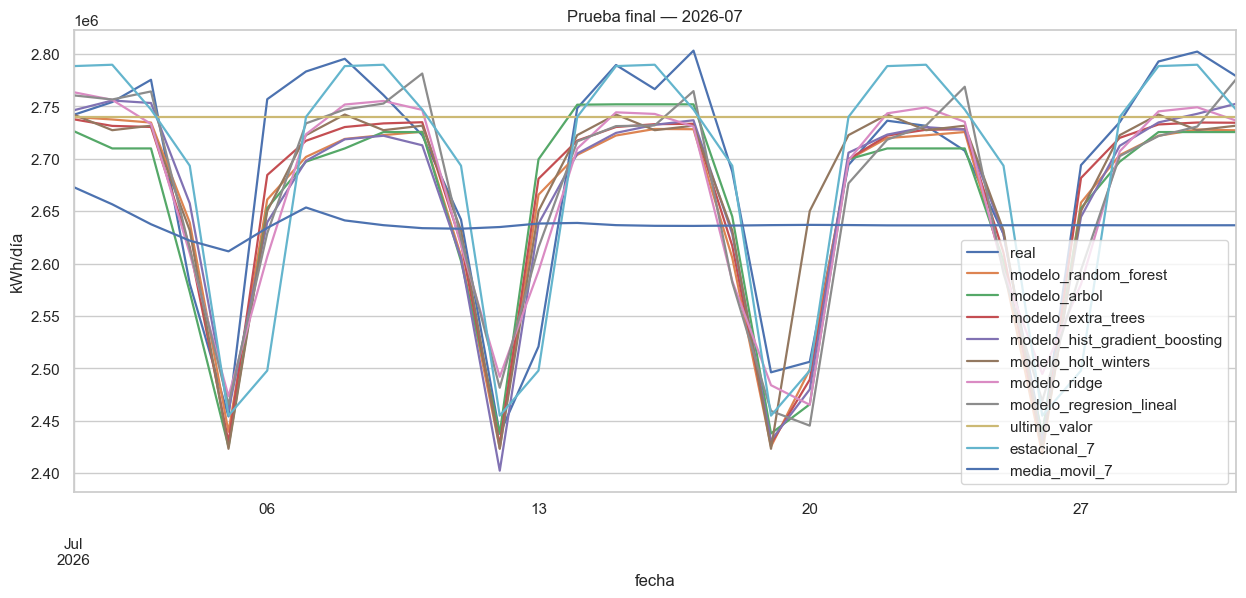

In [35]:
period_mask = monthly_reference["periodo"].dt.to_period("M").eq(OOT_START.to_period("M"))
period_reference = monthly_reference.loc[period_mask]
comparison_rows = [
    {"alternativa": "real", "energia_periodo_kwh": oot_actual.sum()},
    {"alternativa": f"modelo_{SELECTED_FAMILY}", "energia_periodo_kwh": selected_pred.sum()},
]
if not period_reference.empty:
    comparison_rows.insert(1, {
        "alternativa": "proyeccion_referencia",
        "energia_periodo_kwh": period_reference.iloc[0]["proyectada_total_kwh"],
    })
comparison_rows.extend({
    "alternativa": name, "energia_periodo_kwh": oot_predictions[name].sum()
} for name in BASELINES)
monthly_comparison = pd.DataFrame(comparison_rows)
monthly_comparison["error_absoluto_pct"] = (
    (monthly_comparison["energia_periodo_kwh"] - oot_actual.sum()).abs() / oot_actual.sum()
)
display(monthly_comparison.style.format({"energia_periodo_kwh": "{:,.0f}", "error_absoluto_pct": "{:.2%}"}))

ax = oot_predictions.plot(figsize=(15, 6), linewidth=1.6)
ax.set_title(f"Prueba final — {OOT_START:%Y-%m}")
ax.set_ylabel("kWh/día")
plt.show()


{'cobertura_oot': 0.967741935483871, 'ancho_medio_kwh': 230325.87399999984, 'objetivo_nominal': 0.9}


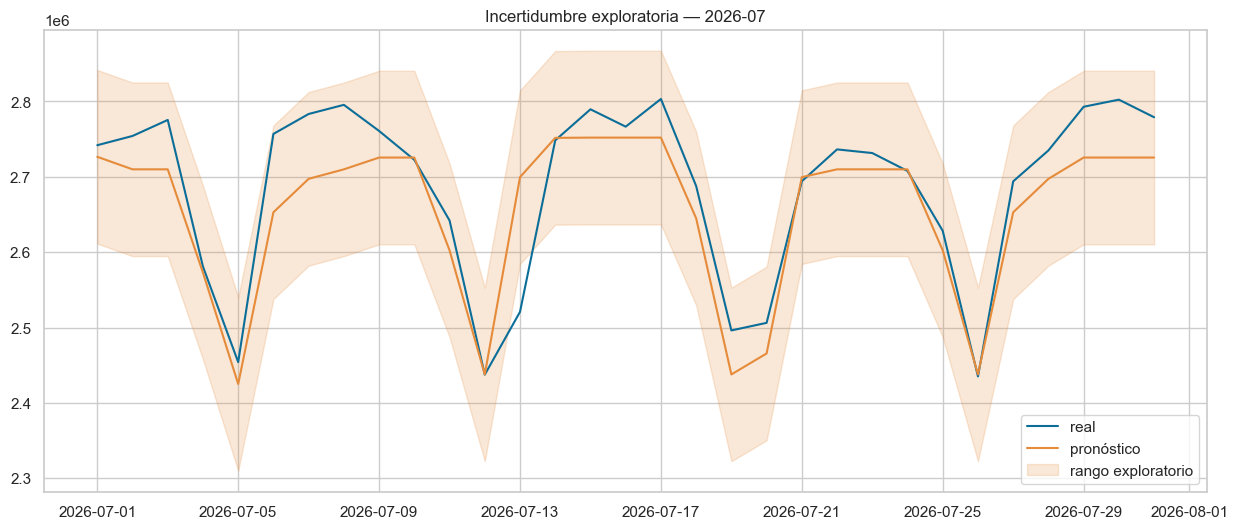

In [36]:
# Intervalo conformal exploratorio: residuales absolutos de octubre–noviembre.
absolute_calibration_error = (calibration_actual - calibration_pred).abs().to_numpy()
n_cal = len(absolute_calibration_error)
quantile_level = min(1.0, np.ceil((n_cal + 1) * (1 - ALPHA_INTERVAL)) / n_cal)
q_error = float(np.quantile(absolute_calibration_error, quantile_level, method="higher"))
interval = pd.DataFrame({
    "real": oot_actual, "prediccion": selected_pred,
    "limite_inferior": np.maximum(0.0, selected_pred - q_error),
    "limite_superior": selected_pred + q_error,
})
coverage = float(((interval["real"] >= interval["limite_inferior"]) &
                  (interval["real"] <= interval["limite_superior"])).mean())
mean_width = float((interval["limite_superior"] - interval["limite_inferior"]).mean())
print({"cobertura_oot": coverage, "ancho_medio_kwh": mean_width, "objetivo_nominal": 1 - ALPHA_INTERVAL})

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(interval.index, interval["real"], label="real", color="#0B6E99")
ax.plot(interval.index, interval["prediccion"], label="pronóstico", color="#E58B3A")
ax.fill_between(interval.index, interval["limite_inferior"], interval["limite_superior"],
                color="#E58B3A", alpha=0.2, label="rango exploratorio")
ax.set_title(f"Incertidumbre exploratoria — {OOT_START:%Y-%m}")
ax.legend()
plt.show()


,variable,importancia_mae,desv
9,dow_sin,"46,701.5751","4,038.6043"
1,lag_7,"21,486.2064","2,926.0496"
14,es_festivo,"19,269.0284","2,562.7925"
0,lag_1,"16,849.0546","1,835.4658"
10,dow_cos,"1,971.7892",626.1761
8,cambio_7,"1,733.7683",702.7541
7,desv_28,748.2928,483.0522
4,media_7,373.2232,454.0328
5,desv_7,261.3312,293.5518
3,lag_28,211.1172,272.7954


,lb_stat,lb_pvalue
7,17.5649,0.0141
14,20.9703,0.1024


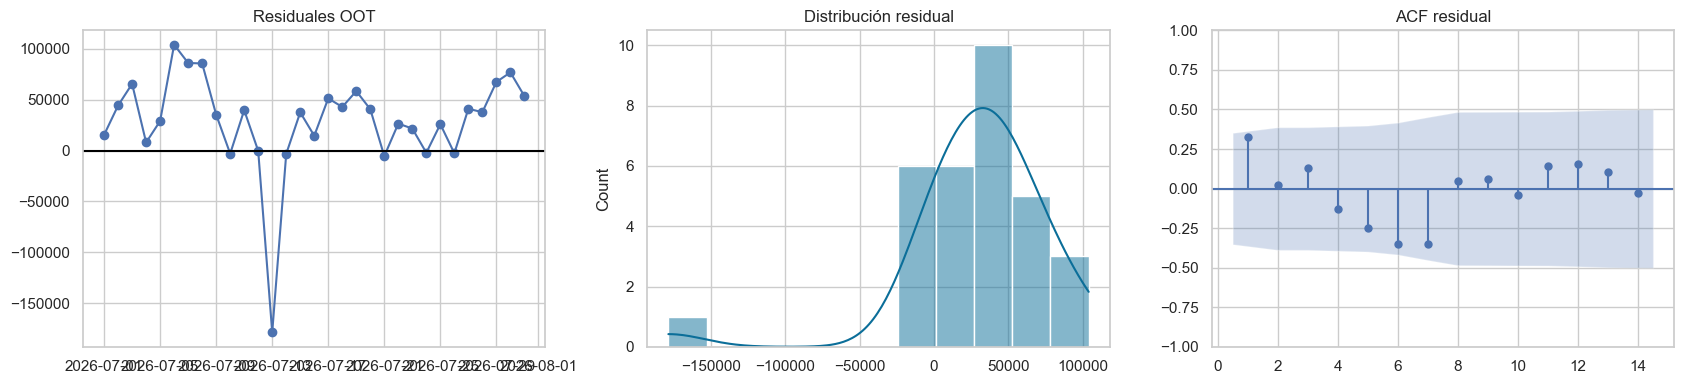

In [37]:
from sklearn.inspection import permutation_importance

if X_final is not None:
    permutation = permutation_importance(
        final_model, X_final.tail(90), y_final.tail(90),
        scoring="neg_mean_absolute_error", n_repeats=20, random_state=SEED, n_jobs=-1,
    )
    importance_table = pd.DataFrame({
        "variable": FEATURE_COLUMNS,
        "importancia_mae": permutation.importances_mean,
        "desv": permutation.importances_std,
    }).sort_values("importancia_mae", ascending=False)
    display(importance_table.head(12))
else:
    importance_table = pd.DataFrame(columns=["variable", "importancia_mae", "desv"])
    display(Markdown(
        "**Interpretabilidad del modelo temporal:** Holt-Winters se explica mediante nivel, tendencia y estacionalidad semanal; la importancia por permutación no aplica."
    ))

residuals_oot = oot_actual - selected_pred
ljung_box = acorr_ljungbox(residuals_oot, lags=[7, 14], return_df=True)
display(ljung_box)
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].plot(residuals_oot.index, residuals_oot, marker="o")
axes[0].axhline(0, color="black")
axes[0].set_title("Residuales OOT")
sns.histplot(residuals_oot, kde=True, ax=axes[1], color="#0B6E99")
axes[1].set_title("Distribución residual")
plot_acf(residuals_oot, lags=min(14, len(residuals_oot) - 1), ax=axes[2], zero=False)
axes[2].set_title("ACF residual")
plt.tight_layout()
plt.show()


In [38]:
selected_oot_row = oot_metrics.loc[oot_metrics["alternativa"].eq(f"modelo_{SELECTED_FAMILY}")].iloc[0]
best_oot_baseline = oot_metrics.loc[oot_metrics["alternativa"].isin(BASELINES)].sort_values("wape").iloc[0]
interval_status = "no alcanza" if coverage < 1 - ALPHA_INTERVAL else "alcanza"

incumbent_row = best_by_family.loc[best_by_family["familia"].eq(CURRENT_CHAMPION_FAMILY)].iloc[0]
incumbent_oot_row = oot_metrics.loc[
    oot_metrics["alternativa"].eq(f"modelo_{CURRENT_CHAMPION_FAMILY}")
].iloc[0]
relative_gain_vs_champion = float(
    (incumbent_row["wape_promedio"] - selected_row["wape_promedio"])
    / incumbent_row["wape_promedio"]
)
new_validation_windows = sum(
    pd.Timestamp(end) > pd.Timestamp("2025-12-31")
    for end in pd.DataFrame(experiment_rows)["fin_validacion"].drop_duplicates()
)
new_validation_windows += int(OOT_END > pd.Timestamp("2025-12-31"))
beats_oot_baseline = bool(selected_oot_row["wape"] < best_oot_baseline["wape"])
beats_oot_champion = bool(selected_oot_row["wape"] < incumbent_oot_row["wape"])

if SELECTED_FAMILY == CURRENT_CHAMPION_FAMILY:
    MODEL_DECISION = "conservar_champion"
    promotion_text = "Extra Trees continúa como champion provisional; no se requiere cambiar el Docker."
elif (
    new_validation_windows >= MIN_NEW_WINDOWS_FOR_PROMOTION
    and relative_gain_vs_champion >= MIN_RELATIVE_GAIN_FOR_PROMOTION
    and beats_oot_baseline
    and beats_oot_champion
):
    MODEL_DECISION = "challenger_listo_para_revision"
    promotion_text = "El challenger mejora al champion en validación y prueba final; queda listo para revisión técnica antes de modificar el Docker."
else:
    MODEL_DECISION = "mantener_champion"
    promotion_text = "La evidencia todavía no alcanza la puerta de promoción; el Docker debe conservar Extra Trees."

display(Markdown(
    f"### Conclusión de prueba final\n\nEl candidato obtiene WAPE de **{selected_oot_row['wape']:.2%}** entre **{OOT_START.date()}** y **{OOT_END.date()}**, frente a **{best_oot_baseline['wape']:.2%}** del mejor baseline. "
    f"El intervalo cubre {coverage:.1%} y {interval_status} el objetivo nominal de {1-ALPHA_INTERVAL:.0%}. "
    f"Extra Trees obtiene **{incumbent_oot_row['wape']:.2%}** en la misma prueba. "
    f"Se contabilizan **{new_validation_windows} ventanas** posteriores a 2025 y una mejora relativa de **{relative_gain_vs_champion:.1%}** frente al champion en validación. {promotion_text}"
))


### Conclusión de prueba final

El candidato obtiene WAPE de **1.57%** entre **2026-07-01** y **2026-07-31**, frente a **1.63%** del mejor baseline. El intervalo cubre 96.8% y alcanza el objetivo nominal de 90%. Extra Trees obtiene **1.43%** en la misma prueba. Se contabilizan **4 ventanas** posteriores a 2025 y una mejora relativa de **4.1%** frente al champion en validación. La evidencia todavía no alcanza la puerta de promoción; el Docker debe conservar Extra Trees.

# Parte VII — Aprendizajes, plan del prototipo y reproducibilidad

## Diario de iteraciones

El objetivo no es ocultar los modelos que rindieron peor. Cada intento registra la hipótesis, el cambio, la evidencia y la decisión que habilitó —o no— el siguiente nivel de complejidad.


In [39]:
iteration_table = pd.DataFrame(iteration_journal)
display(iteration_table)


,iteracion,hipotesis,cambio,evidencia,decision
0,0 — Baseline,La demanda semanal reciente contiene una refer...,"Comparar último valor, patrón de 7 días y medi...",Mejor baseline: estacional_7; WAPE=1.96%.,Todo modelo posterior debe mejorar esta refere...
1,1 — Regresión lineal,Una relación lineal de rezagos y calendario pu...,"Ajustar OLS y auditar VIF, normalidad, homoced...",WAPE=2.04%; VIF máx.=14868.8; Shapiro p=0.0004...,Probar Ridge para controlar colinealidad; cons...
2,2 — Ridge,La regularización estabiliza variables correla...,Comparar cuatro valores de alpha con los mismo...,Mejor ridge_alpha_100; WAPE=1.67%; desviación=...,Probar un árbol únicamente para comprobar si r...
3,3 — Árbol,Reglas no lineales pueden capturar interaccion...,Variar profundidad y mínimo de observaciones p...,Mejor arbol_d8_leaf10; WAPE=1.37%; brecha MAE ...,Probar Random Forest para reducir la varianza ...
4,4 — Random Forest,Promediar árboles reduce la inestabilidad del ...,Entrenar 200 árboles con tres profundidades y ...,Mejor rf_d6_leaf8; WAPE=1.36%; desviación=0.52...,Probar Extra Trees como última complejidad y e...
5,5 — Extra Trees,Cortes más aleatorios reducen varianza sin per...,Comparar profundidad y tamaño de hoja con 250 ...,Mejor et_d8_leaf12; WAPE=1.43%; desviación=0.5...,"Comparar todas las familias por desempeño, est..."
6,6 — HistGradientBoosting,Corregir errores secuencialmente puede mejorar...,Evaluar tres configuraciones predefinidas de t...,Mejor hgb_2; WAPE=1.51%; desviación=0.50%.,Conservar únicamente si la mejora se repite en...
7,7 — Holt-Winters,Una tendencia con estacionalidad semanal explí...,Comparar nivel estacional y tendencia aditiva ...,Mejor holt_winters_2; WAPE=1.59%; desviación=0...,Llevar a selección como alternativa temporal i...


## Plan de implementación del prototipo, priorizado por riesgo

| Prioridad | Riesgo / tarea | Responsable sugerido | Criterio de “terminado” | Respuesta de degradación |
|---|---|---|---|---|
| P0 | Esquema o columnas TC1/TC2 cambian | Datos / calidad | Archivo rechazado con mensaje; cero pérdida silenciosa | Mantener última base versionada y bloquear nueva corrida |
| P0 | Fuga de información en variables | Analítica | Auditoría temporal pasa para todos los pliegues | Desactivar la variable y volver al baseline semanal |
| P0 | Modelo deja de superar baseline | Analítica | WAPE y sesgo monitoreados por periodo | Servir baseline estacional y levantar alerta |
| P1 | Falta TC2 del mes posterior | Datos | Cobertura marcada y conciliación documentada | Ocultar comparaciones incompletas, sin imputar silenciosamente |
| P1 | Deriva de demanda | Analítica / negocio | Umbral de error y sesgo revisado mensualmente | Reentrenar o volver al último modelo aprobado |
| P1 | Tiempo de respuesta >10 s | Backend | Predicción precalculada y filtros agregados | Usar resultados cacheados |
| P2 | Intervalo mal calibrado | Analítica | Cobertura/ancho reportados con más historia | Mostrar rango como exploratorio o retirarlo |
| P2 | Interpretación por usuario | UX / negocio | ≥80% completa el flujo y entiende unidades | Simplificar textos y mostrar baseline junto al modelo |

### Gestión de alcance

El MVP incluye datos, calidad, baselines, un candidato, métricas, pronóstico, rango exploratorio, trazabilidad y exportación. No incluye optimización de compra, oferta real, integración productiva, costos reales, clima obligatorio ni monitoreo continuo. Estas exclusiones evitan convertir un prototipo académico en una promesa comercial.


In [40]:
manual_wape = float((oot_actual - selected_pred).abs().sum() / oot_actual.abs().sum())
reported_wape = float(oot_metrics.loc[
    oot_metrics["alternativa"].eq(f"modelo_{SELECTED_FAMILY}"), "wape"
].iloc[0])

repeat_model, _, _, _ = fit_forecaster(SELECTED_FAMILY, SELECTED_PARAMS, final_train)
repeat_pred = forecast_forecaster(repeat_model, SELECTED_FAMILY, final_train, oot_actual.index)
max_repeat_difference = float((repeat_pred - selected_pred).abs().max())

checks = pd.DataFrame([
    ["2.1 / R1–R18", "Mapa trazable y brechas", len(requirements_map) == 18],
    ["2.2 / R4", "≥8 familias y ≥3 criterios", best_by_family["familia"].nunique() >= 8],
    ["2.3", "ADF, VIF, Shapiro, DW, BP y gráficos", len(vif_table) == len(FEATURE_COLUMNS)],
    ["2.4 / R5", "Pliegues cronológicos", all(train.index.max() < valid.index.min() for _, train, valid in CV_SPLITS)],
    ["2.4 / R6", "Métrica recalculable", abs(manual_wape - reported_wape) <= 1e-12],
    ["2.5", "Ocho iteraciones documentadas", len(iteration_table) >= 8],
    ["2.7 / R9", "Repetición <=1e-6", max_repeat_difference <= 1e-6],
    ["R10", "Periodos TC1/TC2 disponibles", len(quality["monthly_quality"]) >= 13],
    ["R11", "Toda fila válida o marcada", all(
        item["tc2"]["valid_rows"] + item["tc2"].get("invalid_rows", 0) + item["tc2"].get("duplicate_rows", 0) == item["tc2"]["rows"]
        for item in quality["monthly_quality"]
    )],
    ["R14", "Sin identificadores", not privacy_findings],
], columns=["criterio", "evidencia", "aprobado"])
display(checks)
assert checks["aprobado"].all()
print("Máxima diferencia al repetir:", max_repeat_difference)


,criterio,evidencia,aprobado
0,2.1 / R1–R18,Mapa trazable y brechas,True
1,2.2 / R4,≥8 familias y ≥3 criterios,True
2,2.3,"ADF, VIF, Shapiro, DW, BP y gráficos",True
3,2.4 / R5,Pliegues cronológicos,True
4,2.4 / R6,Métrica recalculable,True
5,2.5,Ocho iteraciones documentadas,True
6,2.7 / R9,Repetición <=1e-6,True
7,R10,Periodos TC1/TC2 disponibles,True
8,R11,Toda fila válida o marcada,True
9,R14,Sin identificadores,True


Máxima diferencia al repetir: 0.0


## Documentación necesaria para reproducir

- `Modelo_pronostico_demanda_Modulo2_v4_challengers.ipynb`: experimento champion–challenger completo.
- `Modelo_pronostico_demanda_Modulo2_v3_guiado.ipynb`: evidencia original que se conserva sin cambios.
- `data/processed/base_modelo_diaria.csv`: base final sin identificadores.
- `data/processed/manifest.json`: inventario y hash de las salidas de preparación.
- `data/processed/reporte_calidad.json`: reglas, conteos y conciliaciones.
- `src/preparar_datos_modelo_v3.py`: construcción de la base desde los archivos originales.
- `requirements.txt`: dependencias de experimentación, incluido `statsmodels`.
- `requirements-app.txt`: dependencias separadas del artefacto Docker.

La fecha final se obtiene directamente de la base procesada. El notebook no interpreta la llegada de TC1 y TC2 como demanda real nueva: antes de usar 2026 para evaluar modelos debe comprobarse que el objetivo diario fue incorporado con la misma definición y unidad.


In [41]:
def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
run_dir = OUTPUT_DIR / run_id
run_dir.mkdir(parents=True, exist_ok=True)

best_by_family.to_csv(run_dir / "comparacion_familias.csv", index=False, encoding="utf-8-sig")
pd.DataFrame(experiment_rows).to_csv(run_dir / "resultados_por_fold.csv", index=False, encoding="utf-8-sig")
iteration_table.to_csv(run_dir / "diario_iteraciones.csv", index=False, encoding="utf-8-sig")
requirements_map.to_csv(run_dir / "mapa_requisitos.csv", index=False, encoding="utf-8-sig")
learning_curve.to_csv(run_dir / "curva_aprendizaje.csv", index=False, encoding="utf-8-sig")
oot_metrics.to_csv(run_dir / "metricas_oot.csv", index=False, encoding="utf-8-sig")
oot_export = oot_predictions.copy()
oot_export["limite_inferior"] = interval["limite_inferior"]
oot_export["limite_superior"] = interval["limite_superior"]
oot_export.reset_index(names="fecha").to_csv(run_dir / "predicciones_oot.csv", index=False, encoding="utf-8-sig")

run_log = {
    "run_id": run_id,
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "notebook_version": NOTEBOOK_VERSION,
    "data_file": "data/processed/base_modelo_diaria.csv",
    "data_sha256": file_sha256(DATA_DIR / "base_modelo_diaria.csv"),
    "data_range": [str(DATA_START.date()), str(DATA_END.date())],
    "target": TARGET_COL,
    "seed": SEED,
    "split": {
        "development_end": str(DEVELOPMENT_END.date()),
        "calibration": [str(CALIBRATION_START.date()), str(CALIBRATION_END.date())],
        "out_of_time": [str(OOT_START.date()), str(OOT_END.date())],
        "cv_horizon_days": CV_HORIZON_DAYS,
        "n_cv_splits": N_CV_SPLITS,
    },
    "selected": {"label": SELECTED_LABEL, "family": SELECTED_FAMILY, "params": SELECTED_PARAMS},
    "champion_challenger": {
        "current_champion": CURRENT_CHAMPION_FAMILY, "decision": MODEL_DECISION,
        "new_validation_windows": new_validation_windows,
        "relative_gain_vs_champion": relative_gain_vs_champion,
        "minimum_windows": MIN_NEW_WINDOWS_FOR_PROMOTION,
        "minimum_relative_gain": MIN_RELATIVE_GAIN_FOR_PROMOTION,
    },
    "calibration_metrics": calibration_metrics,
    "oot_metrics": oot_metrics.to_dict(orient="records"),
    "interval": {"alpha": ALPHA_INTERVAL, "coverage": coverage, "mean_width_kwh": mean_width},
    "diagnostics_linear": {
        "adf_p": float(adf_pvalue), "shapiro_p": float(shapiro_p), "durbin_watson": dw_stat,
        "breusch_pagan_p": float(bp_lm_p), "max_finite_vif": max_vif,
    },
    "checks": checks.to_dict(orient="records"),
    "versions": {
        "python": sys.version, "platform": platform.platform(), "pandas": pd.__version__,
        "numpy": np.__version__, "scikit_learn": sklearn.__version__,
        "scipy": scipy.__version__, "statsmodels": statsmodels.__version__,
    },
}
(run_dir / "registro_corrida_guiada.json").write_text(
    json.dumps(run_log, ensure_ascii=False, indent=2, default=str), encoding="utf-8"
)
print(f"Corrida guiada exportada en: {run_dir}")


Corrida guiada exportada en: C:\Users\DARLAN\Documents\Proyecto de grado\pronostico-demanda-energia\outputs\20260912T223128Z
